#  ReelShort データ分析ノートブック

## 使用データについて

本分析では以下のデータを使用しています：

### データソース
| データ | ファイル | 内容 |
|--------|----------|------|
| 日本語版 ReelShort | `all_movies_basic.json` | 日本語版アプリの全1,026作品 |
| 英語版 ReelShort | `all_movies_english_full.json` | 英語版アプリの全1,827作品 |

### 日本語版データの内訳（制作国別）

日本語版ReelShortの1,026作品は、以下のように分類されます：

| 制作国 | 作品数 | 説明 |
|--------|--------|------|
| **RSオリジナル日本** | 17作品 | ReelShortが日本で制作したオリジナルドラマ |
| **アメリカ制作** | 352作品 | 英語版オリジナルを日本語吹き替え |
| **中国制作** | 518作品 | 中国語版オリジナルを日本語吹き替え |
| **タイ制作** | 97作品 | タイ語版オリジナルを日本語吹き替え |
| **その他** | 42作品 | その他アジア地域制作の吹き替え |

### 制作国の判別方法
- `t_book_id`（作品ID）の接頭辞パターンで判別
  - `140000000140000...` → 日本オリジナル
  - `1400...` → アメリカ制作
  - `1490...` → 中国制作
  - `1480...` → タイ制作

### 注意事項
- 「日本語版」≠「日本制作」です
- 日本語版の大半（約98%）は海外制作の吹き替え版です
- 本分析では制作国別に収益性を比較しています


In [136]:
# =============================================
#  初回セットアップ（必要なパッケージのインストール）
# =============================================
# 初回のみ実行してください。2回目以降はスキップしてOKです。

import subprocess
import sys

def install_packages():
    packages = ['pandas', 'numpy', 'matplotlib', 'plotly', 'wordcloud', 'openpyxl']
    for pkg in packages:
        try:
            __import__(pkg)
            print(f" {pkg} - インストール済み")
        except ImportError:
            print(f" {pkg} をインストール中...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
            print(f" {pkg} - インストール完了")


# install_packages()

## 1. データ読み込みと前処理

### 使用データ
- **メインデータ**: 日本語版ReelShort全作品（`all_movies_basic.json`）
- **比較用データ**: 英語版ReelShort全作品（`all_movies_english_full.json`）

### データの取得方法
- ReelShort APIから取得（2024年12月時点）
- 作品情報（タイトル、再生数、いいね数、公開日など）を含む

### 変数名の規則
| 変数名 | 内容 |
|--------|------|
| `df` | 日本語版全作品のDataFrame |
| `df_en` | 英語版全作品のDataFrame |
| `df_ja` | 日本語版のみ（df と同じ） |


In [137]:
# 必要なライブラリのインポート
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# pymongo（bson含む）のインストール
try:
    from bson import ObjectId
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'pymongo', '-q'])
    from bson import ObjectId

# 日本語フォント設定
plt.rcParams['font.family'] = ['DejaVu Sans', 'Noto Sans CJK JP', 'IPAGothic']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Plotly（インタラクティブグラフ用）
PLOTLY_AVAILABLE = False
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
    print("Plotly loaded successfully")
except ImportError:
    print("Plotly not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'plotly', '-q'])
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True

print("All libraries loaded successfully")
print(f"  - bson (ObjectId) available")
print(f"  - PLOTLY_AVAILABLE = {PLOTLY_AVAILABLE}")


Plotly loaded successfully
All libraries loaded successfully
  - bson (ObjectId) available
  - PLOTLY_AVAILABLE = True


In [138]:
# ヘルパー関数
def objectid_to_datetime(oid):
    """MongoDB ObjectIdから作成日時を抽出"""
    if not oid or len(oid) < 8:
        return None
    try:
        timestamp = int(oid[:8], 16)
        return datetime.fromtimestamp(timestamp)
    except:
        return None

def format_number(num):
    """数値をK/M形式でフォーマット"""
    if num >= 1000000:
        return f"{num/1000000:.1f}M"
    elif num >= 1000:
        return f"{num/1000:.1f}K"
    return str(num)

def get_category(t_book_id):
    """t_book_idからカテゴリを判定"""
    if not t_book_id:
        return "不明"
    prefix = t_book_id[:15] if len(t_book_id) >= 15 else t_book_id
    categories = {
        "149000000000000": "英語圏オリジナル",
        "140000000000000": "日本語吹き替え版",
        "149000000000002": "英語圏（シリーズ2）",
        "148000000000000": "中国語圏",
        "149000000000001": "英語圏（シリーズ1）",
        "140000200000000": "日本向けローカライズ",
        "140000000140000": "日本人キャスト",
        "149001000000000": "英語圏（プレミアム）",
        "142600000000002": "スペイン語圏",
        "142600000000000": "スペイン語圏",
        "140000000000002": "日本向け（シリーズ2）",
        "140001000000000": "日本向け（プレミアム）",
        "141000000000000": "韓国語圏",
    }
    return categories.get(prefix, "その他")

def get_region(t_book_id):
    """t_book_idから地域を判定"""
    if not t_book_id:
        return "不明"
    prefix3 = t_book_id[:3] if len(t_book_id) >= 3 else ""
    regions = {
        "149": "英語圏（アメリカ等）",
        "140": "日本",
        "148": "中国語圏",
        "142": "スペイン語圏",
        "141": "韓国語圏",
    }
    return regions.get(prefix3, "その他")

print("ヘルパー関数定義完了！")


ヘルパー関数定義完了！


In [139]:
# データ読み込み
with open('../data/all_movies_basic.json', 'r', encoding='utf-8') as f:
    all_movies = json.load(f)

print(f" 読み込んだ作品数: {len(all_movies)}")

# DataFrameに変換
data = []
for m in all_movies:
    oid = m.get('_id') or m.get('book_id')
    release_dt = objectid_to_datetime(oid)
    t_book_id = m.get('t_book_id', '')
    
    data.append({
        'book_id': m.get('book_id', ''),
        't_book_id': t_book_id,
        'title': m.get('book_title', ''),
        'read_count': m.get('read_count', 0),
        'collect_count': m.get('collect_count', 0),
        'chapter_count': m.get('chapter_count', 0),
        'release_date': release_dt,
        'special_desc': m.get('special_desc', ''),
        'tags': m.get('tag', []),
        'category': get_category(t_book_id),
        'region': get_region(t_book_id),
        'is_japanese_cast': t_book_id.startswith('140000000140000')
    })

df = pd.DataFrame(data)

# 追加の列を作成
df['year_month'] = df['release_date'].apply(lambda x: x.strftime('%Y-%m') if x else None)
df['year'] = df['release_date'].apply(lambda x: x.year if x else None)
df['month'] = df['release_date'].apply(lambda x: x.month if x else None)
df['read_count_log'] = np.log10(df['read_count'].replace(0, 1))

print(f" DataFrame作成完了: {df.shape[0]}行 x {df.shape[1]}列")
df.head()


# =============================================
# グローバルパラメータ定義（収益分析用）
# =============================================
COST_CONFIG = {
    'Japan_Original': 20_000_000,  # 日本オリジナル: 2000万円
    'USA': 3_000_000,              # アメリカ制作（吹き替え）: 300万円
    'China': 3_000_000,            # 中国制作: 300万円
    'Thailand': 3_000_000,         # タイ制作: 300万円
    'Other_Asia': 3_000_000,       # その他アジア: 300万円
    'Other': 3_000_000             # その他: 300万円
}

JPY_PER_EPISODE = 90          # 1話90円（60コイン × 1.5円）
AVG_PURCHASED_EPS = 15        # 課金者平均15話購入
AD_REVENUE_PER_VIEW = 1       # 広告1円/視聴
PLATFORM_SHARE = 0.30         # 手数料30%
FREE_EPS = 10                 # 無料10話

print("収益分析パラメータ設定完了")


 読み込んだ作品数: 1026
 DataFrame作成完了: 1026行 x 16列
収益分析パラメータ設定完了


In [ ]:
# =============================================
# 製作国判定ロジック（統一版）
# =============================================

# === 日本語版ReelShortの製作国判定 ===
def get_origin_ja(t_book_id):
    """
    日本語版ReelShortのt_book_idから製作国を判定
    
    t_book_idプレフィックスルール:
    - 140000000140000xxx: 日本オリジナル（RSオリジナル日本ドラマ）
    - 1400xxx: アメリカ制作
    - 1490xxx: 中国制作
    - 1480xxx: タイ制作
    - 1426xxx: その他アジア（韓国等）
    - その他: 不明/その他
    """
    if pd.isna(t_book_id):
        return 'Other'
    t_book_id = str(t_book_id)
    
    if t_book_id.startswith('140000000140000'):
        return 'Japan_Original'
    elif t_book_id.startswith('1490'):
        return 'China'
    elif t_book_id.startswith('1400'):
        return 'USA'
    elif t_book_id.startswith('1480'):
        return 'Thailand'
    elif t_book_id.startswith('1426'):
        return 'Other_Asia'
    else:
        return 'Other'

# === 英語版ReelShortの製作国判定 ===
def get_origin_en(t_book_id):
    """
    英語版ReelShortのt_book_idから製作国を判定
    
    t_book_idプレフィックスルール:
    - 2000xxx, 2013xxx, 2010xxx: アメリカ制作
    - 2090xxx: 中国制作
    - その他: 不明/その他
    """
    if pd.isna(t_book_id):
        return 'Other'
    t_book_id = str(t_book_id)
    
    if t_book_id.startswith('2000') or t_book_id.startswith('2013') or t_book_id.startswith('2010'):
        return 'USA'
    elif t_book_id.startswith('2090'):
        return 'China'
    else:
        return 'Other'

# === カラーマップとラベル（共通） ===
ORIGIN_COLORS = {
    'Japan_Original': '#FF3366',  # ピンク/赤
    'USA': '#3366FF',             # 青
    'China': '#FFCC00',           # 黄色
    'Thailand': '#33CC99',        # 緑
    'Other_Asia': '#9966FF',      # 紫
    'Other': '#999999'            # グレー
}

ORIGIN_LABELS = {
    'Japan_Original': '日本オリジナル',
    'USA': 'アメリカ制作',
    'China': '中国制作',
    'Thailand': 'タイ制作',
    'Other_Asia': 'その他アジア',
    'Other': 'その他'
}

# 後方互換性のためのエイリアス
origin_colors = ORIGIN_COLORS
origin_labels = ORIGIN_LABELS
get_origin = get_origin_ja  # 日本語版をデフォルトに

print("製作国判定ロジック（統一版）を定義しました")
print("\n日本語版: get_origin_ja(t_book_id) または get_origin(t_book_id)")
print("英語版: get_origin_en(t_book_id)")
print("\nカラーマップ:")
for k, v in ORIGIN_LABELS.items():
    print(f"  {v}: {ORIGIN_COLORS[k]}")


In [ ]:
# =============================================
# 市場スケール情報
# =============================================

# 英語市場と日本市場の再生数スケールの違い
# 英語市場は日本市場より規模が大きい

print("市場スケール参考情報（後で実データから計算）:")
print("  - 英語市場: 全世界配信、再生数が日本市場より大幅に多い")
print("  - 日本市場: 日本国内配信、再生数は英語市場の数分の1程度")
print("\n分析時の注意:")
print("  - 英語作品を日本にローカライズした場合の収益は")
print("    英語市場での収益と合算して評価する必要がある")
print("  - 制作費回収は英語市場がメイン、日本市場は追加収益")


## 2. 基本統計

### 対象データ
**日本語版ReelShort 全1,026作品**

このセクションでは日本語版アプリに配信されている全作品の基本統計を表示します。
（制作国は問わず、日本語版に存在する全ての作品が対象）


In [140]:
# 基本統計情報
print("=" * 60)
print(" 基本統計情報")
print("=" * 60)

stats = {
    '総作品数': len(df),
    '総再生数': df['read_count'].sum(),
    '総いいね数': df['collect_count'].sum(),
    '平均再生数': df['read_count'].mean(),
    '中央値再生数': df['read_count'].median(),
    '最大再生数': df['read_count'].max(),
    '平均エピソード数': df['chapter_count'].mean(),
    '日本人キャスト作品数': df['is_japanese_cast'].sum(),
}

for key, val in stats.items():
    print(f"  {key}: {format_number(int(val))} ({int(val):,})")

# 最も再生された作品TOP5
print("\n 再生数TOP5:")
top5 = df.nlargest(5, 'read_count')[['title', 'read_count', 'category']]
for _, row in top5.iterrows():
    print(f"  {format_number(row['read_count']):>8} | {row['title']} ({row['category']})")


 基本統計情報
  総作品数: 1.0K (1,026)
  総再生数: 1436.1M (1,436,146,756)
  総いいね数: 18.4M (18,402,161)
  平均再生数: 1.4M (1,399,753)
  中央値再生数: 492.4K (492,423)
  最大再生数: 21.7M (21,710,063)
  平均エピソード数: 70 (70)
  日本人キャスト作品数: 17 (17)

 再生数TOP5:
     21.7M | ［吹き替え］私こそが学園のクイーン・ビー (日本向け（プレミアム）)
     20.5M | あなたと出会う運命 (日本語吹き替え版)
     17.7M | 私こそが学園のクイーン・ビー (日本語吹き替え版)
     17.7M | 労働者父が大富豪？！ (中国語圏)
     16.5M | ホームレスの夫が実は大富豪 ～クリスマスの奇跡～ (日本語吹き替え版)


## 3. 再生数分析

### 対象データ
**日本語版ReelShort 全1,026作品**

再生数の分布、トップ作品などを分析します。


In [141]:
#  再生数 vs 公開日 の散布図（Plotly）

df_plot = df[df['release_date'].notna()].copy()

fig = px.scatter(
    df_plot,
    x='release_date',
    y='read_count',
    color='region',
    size='chapter_count',
    size_max=20,
    hover_name='title',
    hover_data={
        'read_count': ':,',
        'collect_count': ':,',
        'category': True,
        'chapter_count': True
    },
    title='日本語のReelShortドラマ、公開日×再生数の分布',
    log_y=True,
    labels={
        'read_count': '再生数',
        'release_date': '公開日',
        'region': '地域',
        'collect_count': 'いいね数',
        'category': 'カテゴリ',
        'chapter_count': 'EP数'
    }
)

fig.update_layout(
    height=600,width=1200,
    hovermode='closest',
    template='plotly_white'
)

fig.show()


## 4. 地域・カテゴリ分析


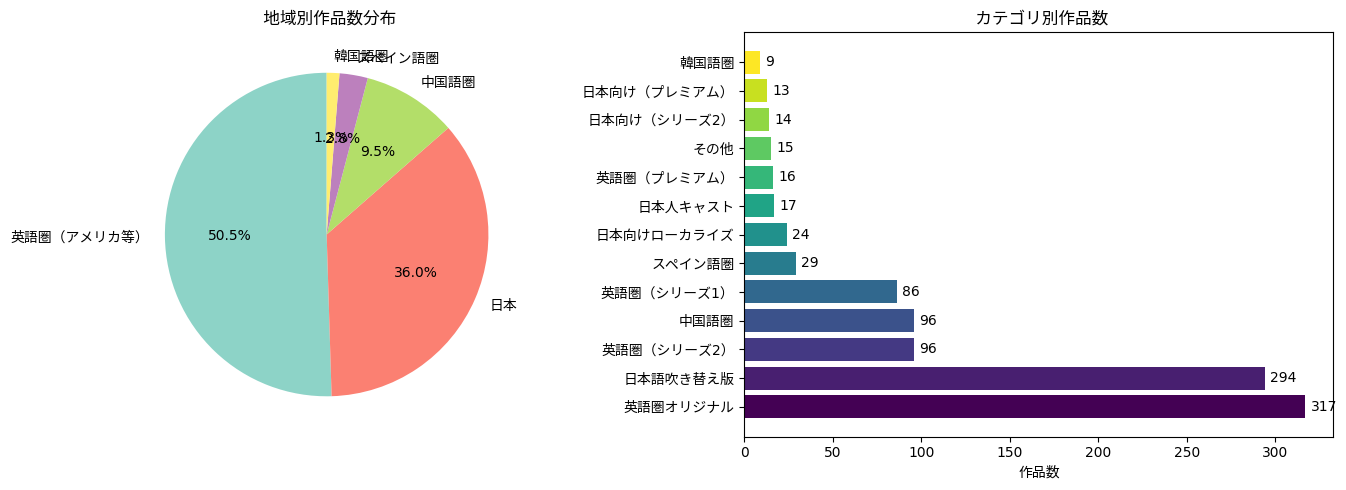

In [142]:
# 地域別・カテゴリ別の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 地域別作品数（円グラフ）
region_counts = df['region'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(region_counts)))
axes[0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(' 地域別作品数分布')

# 右: カテゴリ別作品数（横棒グラフ）
category_counts = df['category'].value_counts()
y_pos = np.arange(len(category_counts))
bars = axes[1].barh(y_pos, category_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(category_counts))))
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(category_counts.index)
axes[1].set_xlabel('作品数')
axes[1].set_title(' カテゴリ別作品数')
for i, (count, bar) in enumerate(zip(category_counts.values, bars)):
    axes[1].text(count + 3, i, str(count), va='center')

plt.tight_layout()
plt.show()


## 5. 時系列分析


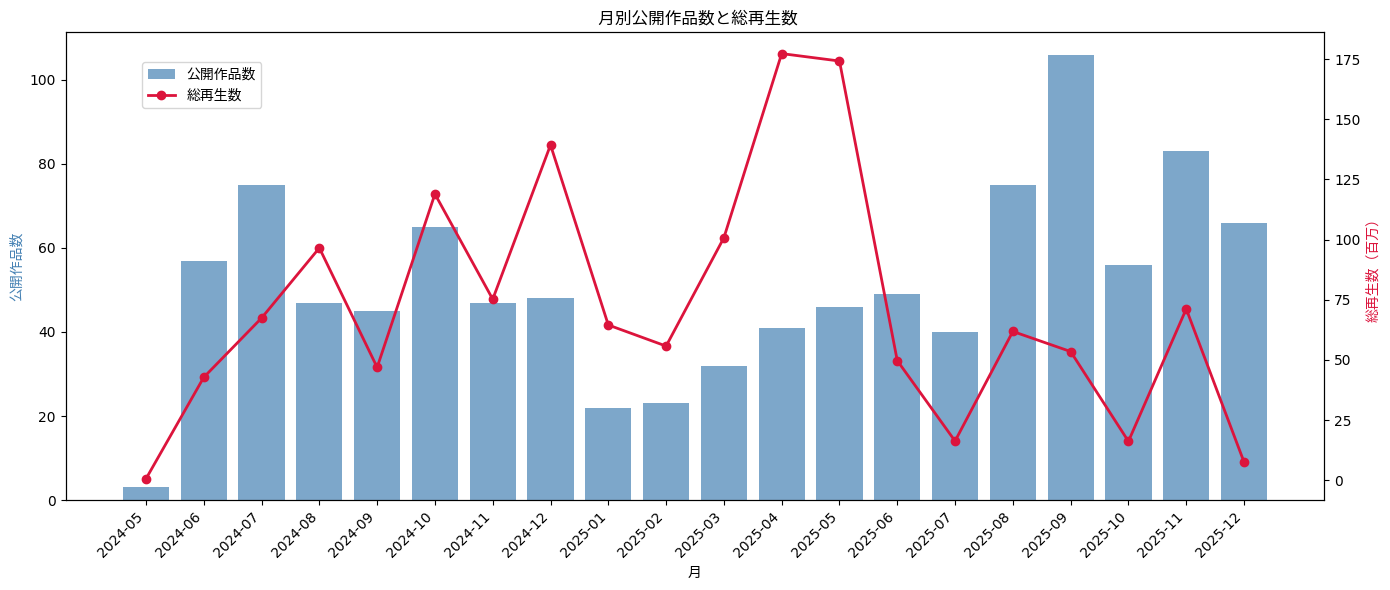

In [143]:
# 月別公開数と累積再生数
df_time = df[df['year_month'].notna()].copy()
monthly = df_time.groupby('year_month').agg({
    'book_id': 'count',
    'read_count': 'sum'
}).rename(columns={'book_id': 'releases', 'read_count': 'total_reads'})

fig, ax1 = plt.subplots(figsize=(14, 6))

# 棒グラフ: 公開数
ax1.bar(range(len(monthly)), monthly['releases'], color='steelblue', alpha=0.7, label='公開作品数')
ax1.set_xlabel('月')
ax1.set_ylabel('公開作品数', color='steelblue')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly.index, rotation=45, ha='right')

# 折れ線グラフ: 再生数
ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['total_reads'] / 1e6, color='crimson', linewidth=2, marker='o', label='総再生数')
ax2.set_ylabel('総再生数（百万）', color='crimson')

plt.title(' 月別公開作品数と総再生数')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()


## 6. 日本人キャスト作品分析 

### 対象データ
**日本語版の中の「RSオリジナル日本ドラマ」17作品のみ**

ここでは、日本で撮影・制作されたReelShortオリジナル作品のみを分析します。

### 判別方法
- `t_book_id`が`140000000140000`で始まる作品
- 日本人キャストによる日本語オリジナル作品

### 他との違い
| 分類 | 説明 |
|------|------|
| RSオリジナル日本（17作品） | 日本で制作されたオリジナル ← **このセクションの対象** |
| アメリカ制作吹き替え（352作品） | 英語版を日本語に吹き替え |
| 中国制作吹き替え（518作品） | 中国語版を日本語に吹き替え |


In [144]:
# 日本人キャスト作品のみ抽出
jp_cast = df[df['is_japanese_cast']].copy()
jp_cast = jp_cast.sort_values('read_count', ascending=False)
jp_cast['rank'] = range(1, len(jp_cast) + 1)

print(f" 日本人キャスト日本オリジナル作品: {len(jp_cast)}作品")
print(f"   総再生数: {format_number(jp_cast['read_count'].sum())}")
print(f"   平均再生数: {format_number(int(jp_cast['read_count'].mean()))}")
print()

# ランキング表示
print("【再生数ランキング】")
print("-" * 70)
for _, row in jp_cast.iterrows():
    date = row['release_date'].strftime('%Y-%m-%d') if row['release_date'] else '不明'
    print(f"{row['rank']:2}. {format_number(row['read_count']):>8} | {row['title'][:35]:<35} | {date}")


 日本人キャスト日本オリジナル作品: 17作品
   総再生数: 94.7M
   平均再生数: 5.6M

【再生数ランキング】
----------------------------------------------------------------------
 1.    14.3M | 令嬢決戦！私こそが学園のクイーン                    | 2025-04-16
 2.    11.6M | ダイヤモンドの再会                           | 2024-12-03
 3.    10.9M | 冷酷御曹司の愛妻計画                          | 2025-04-25
 4.    10.7M | 財閥令嬢様の二重生活                          | 2024-12-10
 5.     9.0M | 嫌いなアイツの専属メイド!?                      | 2025-05-20
 6.     8.4M | 銃と金とクリスマス                           | 2025-05-09
 7.     6.7M | せめて最後に愛のキスを                         | 2025-01-13
 8.     5.3M | 無職の夫は大富豪だった件!                       | 2025-03-14
 9.     3.8M | 消防士の元夫、悔恨の炎に焼かれて                    | 2025-06-30
10.     3.3M | 帰ってきたお嬢様                            | 2025-01-13
11.     2.2M | 一目惚れ！今すぐ結婚してくれますか？                  | 2025-04-08
12.     2.1M | ケーキ職人のワタシが大富豪と偽装結婚した話               | 2025-04-16
13.     1.8M | もう一度、君に恋をする                         | 2025-04-12
14.     1.5M | 負け犬の私がバージンを捨てる！ 

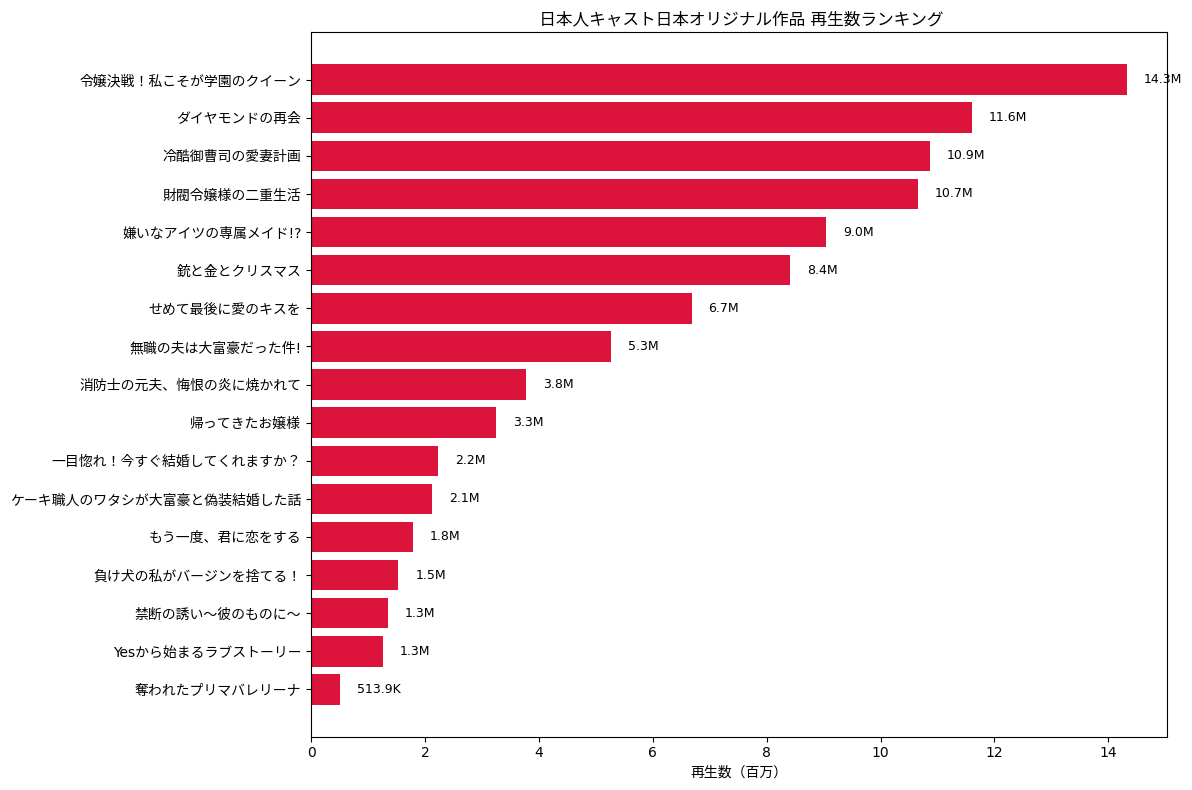

In [145]:
# 日本人キャスト作品の再生数ランキング（横棒グラフ）
jp_sorted = jp_cast.sort_values('read_count', ascending=True)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(jp_sorted))
bars = plt.barh(y_pos, jp_sorted['read_count'] / 1e6, color='crimson')
plt.yticks(y_pos, [t[:25] + '...' if len(t) > 25 else t for t in jp_sorted['title']])
plt.xlabel('再生数（百万）')
plt.title(' 日本人キャスト日本オリジナル作品 再生数ランキング')

for bar, val in zip(bars, jp_sorted['read_count']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             format_number(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 7. タグ分析


 ユニークタグ数: 202


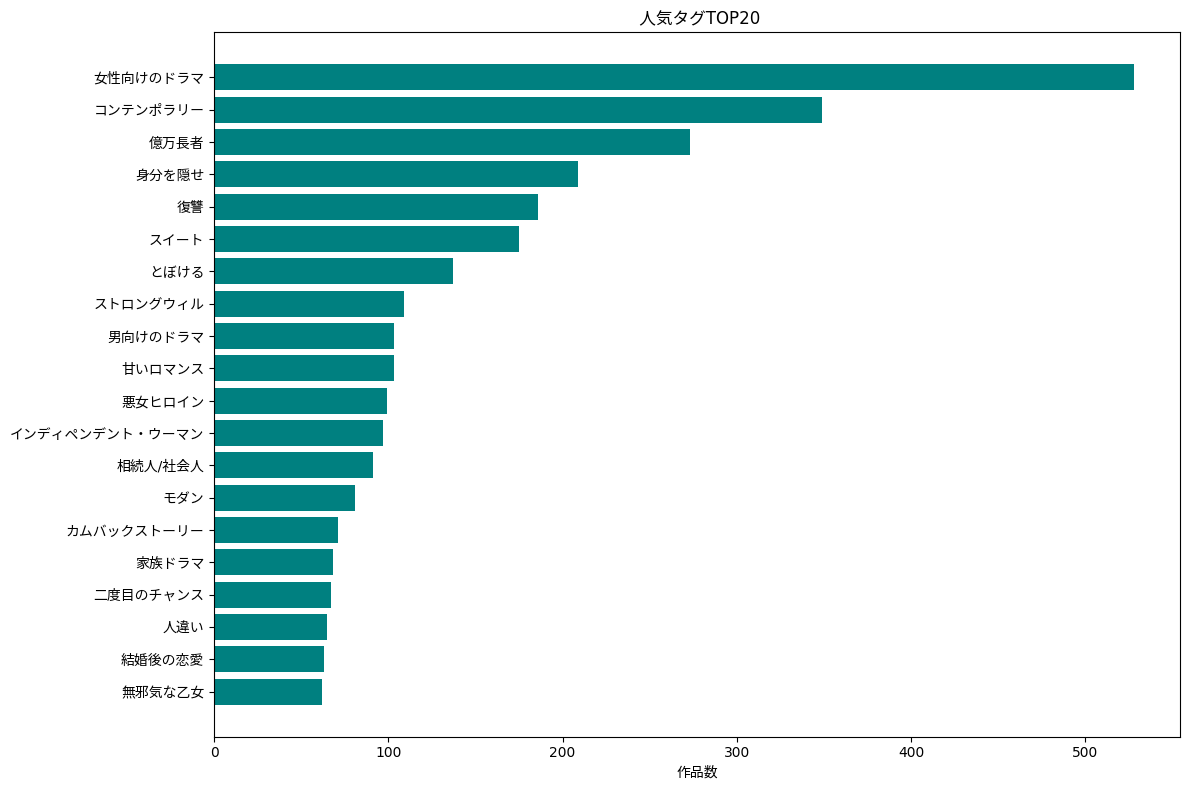

In [146]:
# タグの集計
all_tags = []
for tags in df['tags']:
    if isinstance(tags, list):
        all_tags.extend(tags)

tag_counts = Counter(all_tags)
print(f" ユニークタグ数: {len(tag_counts)}")

# TOP20タグ
top_tags = dict(sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_tags))
plt.barh(y_pos, list(top_tags.values()), color='teal')
plt.yticks(y_pos, list(top_tags.keys()))
plt.xlabel('作品数')
plt.title(' 人気タグTOP20')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. ワードクラウド


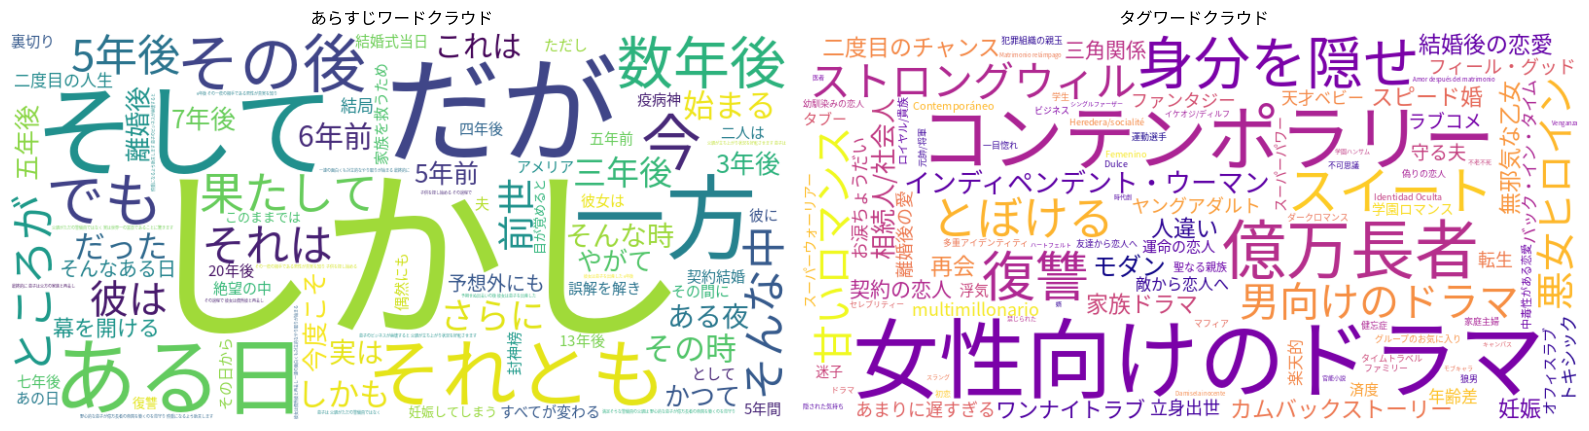

In [147]:
# ワードクラウド生成
try:
    from wordcloud import WordCloud
    import os
    
    # 日本語フォントパス
    font_paths = [
        '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'
    ]
    font_path = None
    for fp in font_paths:
        if os.path.exists(fp):
            font_path = fp
            break
    
    # ストップワード
    stopwords = {'の', 'に', 'は', 'を', 'た', 'が', 'で', 'て', 'と', 'し', 'れ', 'さ', 'ある', 
                 'いる', 'も', 'な', 'こと', 'い', 'や', 'など', 'その', 'から', 'する', 'ない',
                 'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has',
                 'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from', 'and', 'or'}
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左: あらすじワードクラウド
    all_desc = ' '.join(df['special_desc'].dropna().tolist())
    wc1 = WordCloud(width=800, height=400, background_color='white', max_words=150,
                    stopwords=stopwords, font_path=font_path, colormap='viridis')
    wc1.generate(all_desc)
    axes[0].imshow(wc1, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title(' あらすじワードクラウド')
    
    # 右: タグワードクラウド
    wc2 = WordCloud(width=800, height=400, background_color='white', max_words=100,
                    font_path=font_path, colormap='plasma')
    wc2.generate_from_frequencies(tag_counts)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('️ タグワードクラウド')
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ wordcloudがインストールされていません。pip install wordcloud でインストールしてください")


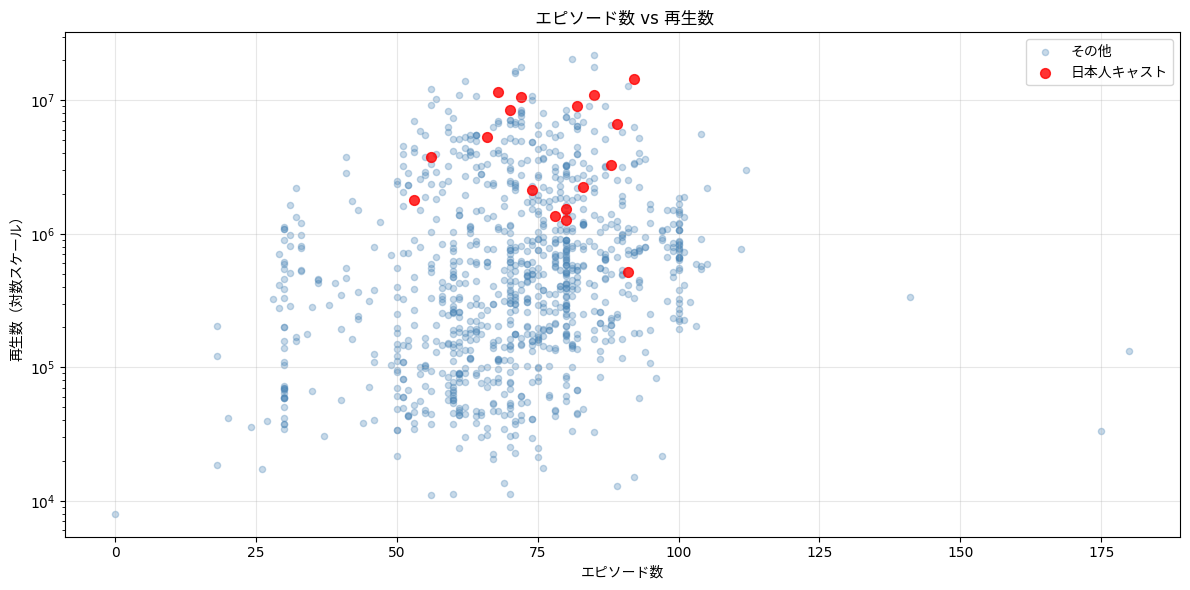


相関係数:
  再生数 vs エピソード数: 0.087
  再生数 vs いいね数: 0.898


In [148]:
# エピソード数 vs 再生数の散布図
plt.figure(figsize=(12, 6))

# 日本人キャストとその他で色分け
colors = df['is_japanese_cast'].map({True: 'red', False: 'steelblue'})
alphas = df['is_japanese_cast'].map({True: 0.8, False: 0.3})

for is_jp in [False, True]:
    subset = df[df['is_japanese_cast'] == is_jp]
    label = '日本人キャスト' if is_jp else 'その他'
    color = 'red' if is_jp else 'steelblue'
    alpha = 0.8 if is_jp else 0.3
    plt.scatter(subset['chapter_count'], subset['read_count'], 
                c=color, alpha=alpha, label=label, s=50 if is_jp else 20)

plt.yscale('log')
plt.xlabel('エピソード数')
plt.ylabel('再生数（対数スケール）')
plt.title(' エピソード数 vs 再生数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 相関係数
print(f"\n相関係数:")
print(f"  再生数 vs エピソード数: {df['read_count'].corr(df['chapter_count']):.3f}")
print(f"  再生数 vs いいね数: {df['read_count'].corr(df['collect_count']):.3f}")


In [149]:
# インタラクティブ: Plotlyで詳細な散布図（利用可能な場合）
if PLOTLY_AVAILABLE:
    fig = px.scatter(
        df,
        x='chapter_count',
        y='read_count',
        color='category',
        hover_name='title',
        hover_data=['region', 'release_date'],
        title=' エピソード数 vs 再生数（インタラクティブ - ホバーで詳細表示）',
        labels={'chapter_count': 'エピソード数', 'read_count': '再生数', 'category': 'カテゴリ'},
        log_y=True,
        size_max=30
    )
    fig.update_layout(height=700, width=1400)
    fig.show()


## 10. 英語版 vs 日本語版 比較分析 

### 対象データ
| データ | 作品数 | 説明 |
|--------|--------|------|
| 英語版 ReelShort | 1,827作品 | 主に英語圏向けアプリのデータ |
| 日本語版 ReelShort | 1,026作品 | 日本向けアプリのデータ |

### 比較の目的
- 英語版と日本語版で人気作品の傾向が異なるか
- 再生数の規模感の違い
- 公開タイミングの違い

### 注意点
- 英語版の作品が日本語版に吹き替えられて配信されている場合がある
- 同じ作品でも両版で再生数が異なる


In [150]:
#  英語版データ読み込み

EN_DATA_PATH = '../data/all_movies_english_full.json'
try:
    with open(EN_DATA_PATH, 'r', encoding='utf-8') as f:
        en_movies = json.load(f)
    print(f' 英語版データ: {len(en_movies)}作品')
except FileNotFoundError:
    print('⚠️ 英語版データなし。data/all_movies_english_full.json が必要です')
    en_movies = []

# DataFrame作成
en_data = []
for m in en_movies:
    oid = m.get('_id') or m.get('book_id')
    release_dt = objectid_to_datetime(oid)
    t_book_id = m.get('t_book_id', '')
    title = m.get('book_title', '')
    prefix_15 = t_book_id[:15] if len(t_book_id) >= 15 else ''
    
    # コンテンツ種類判定
    if 'English-dubbed' in title or 'dubbed' in title.lower():
        content_type = ' 吹き替え版'
    elif prefix_15.startswith('209001') or prefix_15.startswith('201001'):
        content_type = ' 吹き替え版'
    elif prefix_15 == '200000800000000':
        content_type = ' ReelTalk'
    elif prefix_15.startswith('208'):
        content_type = ' 特別コンテンツ'
    elif prefix_15 == '200000200000000':
        content_type = '⭐ プレミアム'
    elif prefix_15.startswith('209000') or prefix_15.startswith('200000000'):
        content_type = ' オリジナル'
    else:
        content_type = ' その他'
    
    en_data.append({
        'book_id': m.get('book_id', ''),
        't_book_id': t_book_id,
        'title': title,
        'read_count': m.get('read_count', 0),
        'collect_count': m.get('collect_count', 0),
        'chapter_count': m.get('chapter_count', 0),
        'release_date': release_dt,
        'year_month': release_dt.strftime('%Y-%m') if release_dt else None,
        'tags': m.get('tag', []),
        'content_type': content_type,
        'prefix_15': prefix_15,
        'lang': 'English'
    })

df_en = pd.DataFrame(en_data)
print(f' 英語版DataFrame: {len(df_en)}行')


 英語版データ: 1827作品
 英語版DataFrame: 1827行


In [151]:
#  統計比較テーブル

if len(df_en) > 0:
    comparison_data = {
        '項目': ['作品数', '総再生数', '総いいね', '平均再生数', '中央値', '最大再生数'],
        ' 英語版': [
            f"{len(df_en):,}",
            f"{df_en['read_count'].sum():,.0f}",
            f"{df_en['collect_count'].sum():,.0f}",
            f"{df_en['read_count'].mean():,.0f}",
            f"{df_en['read_count'].median():,.0f}",
            f"{df_en['read_count'].max():,.0f}"
        ],
        ' 日本語版': [
            f"{len(df):,}",
            f"{df['read_count'].sum():,.0f}",
            f"{df['collect_count'].sum():,.0f}",
            f"{df['read_count'].mean():,.0f}",
            f"{df['read_count'].median():,.0f}",
            f"{df['read_count'].max():,.0f}"
        ],
        '倍率': [
            f"{len(df_en)/len(df):.1f}x",
            f"{df_en['read_count'].sum()/df['read_count'].sum():.1f}x",
            f"{df_en['collect_count'].sum()/df['collect_count'].sum():.1f}x",
            f"{df_en['read_count'].mean()/df['read_count'].mean():.1f}x",
            f"{df_en['read_count'].median()/df['read_count'].median():.1f}x",
            f"{df_en['read_count'].max()/df['read_count'].max():.1f}x"
        ]
    }
    comparison_df = pd.DataFrame(comparison_data)
    print(' 英語版 vs 日本語版 統計比較')
    print('=' * 70)
    print(comparison_df.to_string(index=False))


 英語版 vs 日本語版 統計比較
   項目            英語版          日本語版    倍率
  作品数          1,827         1,026  1.8x
 総再生数 24,194,833,072 1,436,146,756 16.8x
 総いいね    244,850,646    18,402,161 13.3x
平均再生数     13,242,930     1,399,753  9.5x
  中央値      1,307,763       492,423  2.7x
最大再生数    503,653,071    21,710,063 23.2x


In [152]:
#  再生数分布比較（箱ひげ図）

if len(df_en) > 0:
    df['lang'] = 'Japanese'
    df_combined = pd.concat([
        df_en[['title', 'read_count', 'lang']],
        df[['title', 'read_count', 'lang']]
    ], ignore_index=True)
    
    fig = px.box(
        df_combined,
        x='lang',
        y='read_count',
        color='lang',
        title=' 再生数分布比較（英語版 vs 日本語版）',
        labels={'read_count': '再生数', 'lang': '言語'},
        log_y=True,
        color_discrete_map={'English': 'steelblue', 'Japanese': 'crimson'}
    )
    fig.update_layout(height=500, showlegend=False)
    fig.show()


In [153]:
#  再生数TOP20比較（横並び）

if len(df_en) > 0:
    top20_en = df_en.nlargest(20, 'read_count')[['title', 'read_count', 'content_type']]
    top20_ja = df.nlargest(20, 'read_count')[['title', 'read_count', 'category']]
    
    fig = make_subplots(rows=1, cols=2,
                         subplot_titles=[' 英語版 TOP20', ' 日本語版 TOP20'],
                         horizontal_spacing=0.12)
    
    # 英語版
    fig.add_trace(
        go.Bar(y=top20_en['title'].str[:30][::-1], 
               x=top20_en['read_count'][::-1]/1e6,
               orientation='h', marker_color='steelblue',
               text=[f"{x/1e6:.0f}M" for x in top20_en['read_count'][::-1]],
               textposition='outside'),
        row=1, col=1
    )
    
    # 日本語版
    fig.add_trace(
        go.Bar(y=top20_ja['title'].str[:30][::-1],
               x=top20_ja['read_count'][::-1]/1e6,
               orientation='h', marker_color='crimson',
               text=[f"{x/1e6:.1f}M" for x in top20_ja['read_count'][::-1]],
               textposition='outside'),
        row=1, col=2
    )
    
    fig.update_layout(height=800, width=1600, showlegend=False,
                      title_text=' 再生数TOP20比較')
    fig.update_xaxes(title_text='再生数（百万）', row=1, col=1)
    fig.update_xaxes(title_text='再生数（百万）', row=1, col=2)
    fig.show()


In [154]:
#  再生数TOP20比較（重ねて表示）

if len(df_en) > 0:
    # 英語版・日本語版TOP20を準備
    top20_en = df_en.nlargest(20, 'read_count')[['title', 'read_count']]
    top20_ja = df.nlargest(20, 'read_count')[['title', 'read_count']]
    
    # タイトルで共通化したい場合は結合する（タイトルで内部的に一致する前提・必要に応じて調整）
    df_top = pd.merge(
        top20_ja.rename(columns={'read_count': 'read_count_ja'}),
        top20_en.rename(columns={'read_count': 'read_count_en'}),
        on='title', how='outer'
    )
    # 欠損値を0に
    df_top['read_count_ja'] = df_top['read_count_ja'].fillna(0)
    df_top['read_count_en'] = df_top['read_count_en'].fillna(0)
    
    # 日本語・英語どちらかのTop20作品 → 40作品弱になる場合もあり
    # 棒グラフ順序揃える（合計値順 or 和順）
    df_top['sum'] = df_top['read_count_ja'] + df_top['read_count_en']
    df_top = df_top.sort_values('sum', ascending=False)
    
    # プロット
    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=df_top['title'].str[:30][::-1],
        x=df_top['read_count_en'][::-1]/1e6,
        orientation='h',
        name="English",
        marker_color='steelblue',
        text=[f"{x/1e6:.0f}M" if x > 0 else "" for x in df_top['read_count_en'][::-1]],
        textposition='outside'
    ))
    fig.add_trace(go.Bar(
        y=df_top['title'].str[:30][::-1],
        x=df_top['read_count_ja'][::-1]/1e6,
        orientation='h',
        name="Japanese",
        marker_color='crimson',
        text=[f"{x/1e6:.1f}M" if x > 0 else "" for x in df_top['read_count_ja'][::-1]],
        textposition='outside'
    ))

    fig.update_layout(
        barmode='group',    # あるいは'barmode="overlay"'で重ねもOK
        height=900,
        width=1000,
        title=' 再生数TOP20 英語/日本語, トップは5億vs2000万(25倍)',
        xaxis_title='再生数（百万）',
        yaxis_title='タイトル',
        legend=dict(title='言語')
    )
    fig.show()


In [155]:
#  英語版コンテンツ種類別分析

if len(df_en) > 0:
    content_stats = df_en.groupby('content_type').agg({
        'book_id': 'count',
        'read_count': ['sum', 'mean']
    }).reset_index()
    content_stats.columns = ['コンテンツ種類', '作品数', '総再生数', '平均再生数']
    content_stats = content_stats.sort_values('総再生数', ascending=False)
    
    print(' 英語版 コンテンツ種類別統計')
    print('=' * 80)
    for _, row in content_stats.iterrows():
        print(f"{row['コンテンツ種類']:<18} | {row['作品数']:>5}作品 | 総再生: {row['総再生数']:>13,.0f} | 平均: {row['平均再生数']:>10,.0f}")
    
    # 円グラフ
    fig = px.pie(
        content_stats,
        values='作品数',
        names='コンテンツ種類',
        title=' 英語版 コンテンツ種類別シェア',
        hole=0.4
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.update_layout(height=500)
    fig.show()


 英語版 コンテンツ種類別統計
 オリジナル             |  1381作品 | 総再生: 21,561,012,324 | 平均: 15,612,608
 特別コンテンツ           |   214作品 | 総再生: 1,220,700,492 | 平均:  5,704,208
⭐ プレミアム            |    27作品 | 総再生:   783,827,109 | 平均: 29,030,634
 その他               |    96作品 | 総再生:   400,761,596 | 平均:  4,174,600
 吹き替え版             |    62作品 | 総再生:   207,728,977 | 平均:  3,350,467
 ReelTalk          |    47作品 | 総再生:    20,802,574 | 平均:    442,608


In [156]:
#  再生数 vs 公開日（両言語比較 + RSオリジナル日本ドラマ色分け）
# カラーマップが反映されない理由を調査するため、値やカテゴリ名のズレもチェック

if 'df_en' not in dir() or df_en is None:
    print("⚠️ 英語版データ(df_en)が読み込まれていません")
    print("   → 先に「10. 英語版 vs 日本語版 比較分析」セクションを実行してください")
elif len(df_en) > 0:
    # 日本語版データ準備
    df_ja_plot = df[df['release_date'].notna()].copy()

    # RSオリジナル日本ドラマ判定（is_japanese_castフラグを使用）
    df_ja_plot['content_type'] = df_ja_plot['is_japanese_cast'].map({
        True: ' 日本人キャストのドラマ',
        False: ' 日本語版（吹き替え等）'
    })

    # 英語版データ準備
    df_en_plot = df_en[df_en['release_date'].notna()].copy()
    df_en_plot['content_type'] = ' 英語版'

    # 点の大きさ列 (日本人キャストだけ大きく)
    def get_marker_size(row):
        if row['content_type'] == ' 日本人キャストのドラマ':
            return 9  # 大きな点
        elif row['content_type'] == ' 英語版':
            return 2   # デフォルト点サイズ
        elif row['content_type'] == ' 日本語版（吹き替え等）':
            return 2
        else:
            return 2

    # 結合
    df_scatter = pd.concat([
        df_en_plot[['title', 'read_count', 'release_date', 'content_type']],
        df_ja_plot[['title', 'read_count', 'release_date', 'content_type']]
    ])
    df_scatter['marker_size'] = df_scatter.apply(get_marker_size, axis=1)

    # 値を確認してからカラーマップ定義し、不一致対策する
    print(f" color_map用カテゴリ値一覧: {df_scatter['content_type'].unique()}")
    # [' 英語版' ' 日本人キャストのドラマ' ' 日本語版（吹き替え等）']

    # カラーマップ（日本キャストを圧倒的に目立たせる）
    color_map = {
        ' 日本人キャストのドラマ': 'blue',      # ★ 真っ赤（最も目立つ）
        ' 英語版': 'grey',             # ビビッドなブルー（英語版）
        ' 日本語版（吹き替え等）': 'crimson'   # オレンジ（日本語版）
    }

    # px.scatterのcolor/categoriesがcolor_mapのキーに完全一致している必要あり
    # カテゴリがNaNや想定外の場合には値を明示チェック
    unmatched = set(df_scatter['content_type'].unique()) - set(color_map.keys())
    if unmatched:
        print("⚠️ color_mapに未定義のカテゴリ: ", unmatched)

    # PlotlyExpressのscatterでmarker sizeを反映
    fig = px.scatter(
        df_scatter,
        x='release_date',
        y='read_count',
        color='content_type',
        hover_name='title',
        hover_data={'read_count': ':,'},
        title=' 再生数 vs 公開日（英語版/日本語版/RSオリジナル日本ドラマ色分け）',
        labels={
            'read_count': '再生数',
            'release_date': '公開日',
            'content_type': 'コンテンツ種類'
        },
        log_y=True,
        opacity=0.6,
        color_discrete_map=color_map, # 完全一致した場合のみカラーマップ適用される
        size='marker_size',   # <-- ここで点の大きさを指定
        size_max=18           # 最大サイズ（日本人キャストを目立たせる）
    )

    fig.update_layout(
        height=600,
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )

    fig.show()

    # 統計表示
    print('\n コンテンツ種類別統計:')
    for ct in color_map.keys():
        subset = df_scatter[df_scatter['content_type'] == ct]
        print(f"  {ct}: {len(subset):,}作品, 平均再生数: {subset['read_count'].mean():,.0f}")


 color_map用カテゴリ値一覧: [' 英語版' ' 日本語版（吹き替え等）' ' 日本人キャストのドラマ']



 コンテンツ種類別統計:
   日本人キャストのドラマ: 17作品, 平均再生数: 5,568,010
   英語版: 1,827作品, 平均再生数: 13,242,930
   日本語版（吹き替え等）: 1,009作品, 平均再生数: 1,329,525


In [157]:
#  吹き替え版（English-dubbed）詳細分析

if len(df_en) > 0:
    dubbed = df_en[df_en['content_type'] == ' 吹き替え版']
    original = df_en[df_en['content_type'] == ' オリジナル']
    
    print(' オリジナル vs 吹き替え版')
    print('=' * 70)
    print(f"{'項目':<15} {' オリジナル':>18} {' 吹き替え版':>18}")
    print('-' * 70)
    print(f"{'作品数':<15} {len(original):>18,} {len(dubbed):>18,}")
    print(f"{'総再生数':<15} {original['read_count'].sum():>18,} {dubbed['read_count'].sum():>18,}")
    print(f"{'平均再生数':<15} {original['read_count'].mean():>18,.0f} {dubbed['read_count'].mean():>18,.0f}")
    
    if len(dubbed) > 0:
        print('\n 吹き替え版 TOP5:')
        for i, (_, row) in enumerate(dubbed.nlargest(5, 'read_count').iterrows(), 1):
            print(f"  {i}. {row['read_count']:>10,} | {row['title'][:45]}")


 オリジナル vs 吹き替え版
項目                           オリジナル              吹き替え版
----------------------------------------------------------------------
作品数                          1,381                 62
総再生数                21,561,012,324        207,728,977
平均再生数                   15,612,608          3,350,467

 吹き替え版 TOP5:
  1. 11,647,647 | I Gave My wife A Red Tasseled Spear (English-
  2. 11,376,954 | CEO, That Intern is Actually Your Wife (Engli
  3. 10,560,565 | Sweet Debt, Secret Billionaire (English-dubbe
  4.  9,727,902 | The Wife I Despised Is My First Love?! (Engli
  5.  9,412,331 | Marrying A Millionaire with My Baby (English-


In [158]:
#  月別公開作品数推移（比較）

if len(df_en) > 0:
    monthly_en = df_en[df_en['year_month'].notna()].groupby('year_month').size().reset_index(name='count')
    monthly_en['lang'] = 'English'
    
    monthly_ja = df[df['year_month'].notna()].groupby('year_month').size().reset_index(name='count')
    monthly_ja['lang'] = 'Japanese'
    
    monthly_combined = pd.concat([monthly_en, monthly_ja])
    
    fig = px.line(
        monthly_combined,
        x='year_month',
        y='count',
        color='lang',
        title=' 月別公開作品数推移（英語版 vs 日本語版）',
        labels={'count': '作品数', 'year_month': '月', 'lang': '言語'},
        markers=True,
        color_discrete_map={'English': 'steelblue', 'Japanese': 'crimson'}
    )
    fig.update_layout(height=500)
    fig.show()


In [159]:
# =============================================
#  カスタム分析用セル
# =============================================
# 以下のコードを変更して、独自の分析を行ってください

# 例1: 特定のタグを持つ作品を抽出
# target_tag = "億万長者"
# df_filtered = df[df['tags'].apply(lambda x: target_tag in x if isinstance(x, list) else False)]
# df_filtered[['title', 'read_count', 'category']].head(10)

# 例2: 特定の期間の作品を抽出
# df_2025 = df[df['year'] == 2025]
# df_2025.groupby('month')['read_count'].sum()

# 例3: カテゴリ別の統計
print(" カテゴリ別統計:")
category_summary = df.groupby('category').agg({
    'read_count': ['count', 'sum', 'mean'],
    'collect_count': 'sum',
    'chapter_count': 'mean'
}).round(0)
category_summary.columns = ['作品数', '総再生数', '平均再生数', '総いいね', '平均EP']
category_summary = category_summary.sort_values('作品数', ascending=False)
display(category_summary)


 カテゴリ別統計:


,作品数,総再生数,平均再生数,総いいね,平均EP
category,,,,,
英語圏オリジナル,317,256422808,808905.0,1665029,77.0
日本語吹き替え版,294,770019882,2619115.0,11851533,71.0
英語圏（シリーズ2）,96,19367579,201746.0,212246,71.0
中国語圏,96,83080842,865425.0,1123177,50.0
英語圏（シリーズ1）,86,45353234,527363.0,290116,77.0
スペイン語圏,29,6108345,210633.0,83858,55.0
日本向けローカライズ,24,27899220,1162468.0,555589,70.0
日本人キャスト,17,94656175,5568010.0,939190,77.0
英語圏（プレミアム）,16,31417328,1963583.0,254900,65.0


In [160]:
# =============================================
#  データエクスポート
# =============================================
# コメントを外して実行すると、データをCSV/Excelにエクスポートできます

# 全作品データをCSVにエクスポート
# df.to_csv('analysis_export_all.csv', index=False, encoding='utf-8-sig')
# print(" CSVにエクスポートしました: analysis_export_all.csv")

# 日本人キャスト作品をExcelにエクスポート
# jp_cast.to_excel('analysis_export_japanese_cast.xlsx', index=False)
# print(" Excelにエクスポートしました: analysis_export_japanese_cast.xlsx")

print(" データをエクスポートするには、上のコメントを外して実行してください")


 データをエクスポートするには、上のコメントを外して実行してください


## 11. テキストマイニング比較（日本語版 vs 英語版）

### 対象データ
- **日本語版**: 全1,026作品のタグ・タイトル
- **英語版**: 全1,827作品のタグ・タイトル

### 分析内容
- タグの頻度比較
- タイトルのキーワード分析
- 人気ジャンルの違い


In [161]:
#  タグ頻度比較（日本語版 vs 英語版）

from collections import Counter

# 日本語版タグ集計
ja_tags = []
for tags in df['tags'].dropna():
    if isinstance(tags, list):
        ja_tags.extend(tags)
    elif isinstance(tags, str):
        ja_tags.extend([t.strip() for t in tags.split(',')])

ja_tag_counts = Counter(ja_tags)

# 英語版タグ集計
en_tags = []
if 'df_en' in dir() and len(df_en) > 0:
    for tags in df_en['tags'].dropna():
        if isinstance(tags, list):
            en_tags.extend(tags)
        elif isinstance(tags, str):
            en_tags.extend([t.strip() for t in tags.split(',')])

en_tag_counts = Counter(en_tags)

# 上位20タグを比較表示
print(" タグ頻度比較 TOP 20")
print("=" * 70)
print(f"{' 日本語版':<35} | {' 英語版':<35}")
print("-" * 70)

ja_top = ja_tag_counts.most_common(20)
en_top = en_tag_counts.most_common(20)

for i in range(20):
    ja_str = f"{ja_top[i][0]}: {ja_top[i][1]}" if i < len(ja_top) else ""
    en_str = f"{en_top[i][0]}: {en_top[i][1]}" if i < len(en_top) else ""
    print(f"{ja_str:<35} | {en_str:<35}")


 タグ頻度比較 TOP 20
 日本語版                               |  英語版                               
----------------------------------------------------------------------
女性向けのドラマ: 528                       | Female: 941                        
コンテンポラリー: 349                       | Contemporary: 758                  
億万長者: 273                           | Billionaire: 518                   
身分を隠せ: 209                          | Revenge: 412                       
復讐: 186                             | Sweet: 353                         
スイート: 175                           | Hidden Identity: 347               
とぼける: 137                           | Strong-Willed: 241                 
ストロングウィル: 109                       | Independent Woman: 226             
男向けのドラマ: 103                        | Playing Dumb: 217                  
甘いロマンス: 103                         | Male: 211                          
悪女ヒロイン: 99                          | Strong Heroine: 183                
インディペンデント・ウーマン: 97        

In [162]:
#  タグ頻度グラフ（日英比較）

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(" 日本語版 タグTOP15", " 英語版 タグTOP15")
)

# 日本語版
ja_top15 = ja_tag_counts.most_common(15)
fig.add_trace(
    go.Bar(
        y=[t[0] for t in ja_top15][::-1],
        x=[t[1] for t in ja_top15][::-1],
        orientation='h',
        marker_color='crimson',
        name='日本語版'
    ),
    row=1, col=1
)

# 英語版
if en_tag_counts:
    en_top15 = en_tag_counts.most_common(15)
    fig.add_trace(
        go.Bar(
            y=[t[0] for t in en_top15][::-1],
            x=[t[1] for t in en_top15][::-1],
            orientation='h',
            marker_color='steelblue',
            name='英語版'
        ),
        row=1, col=2
    )

fig.update_layout(
    height=500,
    showlegend=False,
    title_text=" タグ頻度比較（日本語版 vs 英語版）"
)

fig.show()


In [163]:
#  タイトル頻出単語分析

import re

# 英語版タイトルから単語抽出
def extract_words(text):
    """英語テキストから単語を抽出"""
    words = re.findall(r'[a-zA-Z]+', str(text).lower())
    # ストップワード除外
    stopwords = {'the', 'a', 'an', 'of', 'in', 'to', 'and', 'is', 'my', 'his', 'her', 'for', 'with', 'on', 's', 'i', 'me'}
    return [w for w in words if len(w) > 2 and w not in stopwords]

if 'df_en' in dir() and len(df_en) > 0:
    en_title_words = []
    for title in df_en['title']:
        en_title_words.extend(extract_words(title))
    
    en_word_counts = Counter(en_title_words)
    
    print(" 英語版タイトル 頻出単語 TOP 30")
    print("=" * 50)
    for word, count in en_word_counts.most_common(30):
        bar = "█" * min(count // 10, 30)
        print(f"{word:<15} {count:>4} {bar}")
else:
    print("⚠️ 英語版データが読み込まれていません")


 英語版タイトル 頻出単語 TOP 30
love             215 █████████████████████
ceo              129 ████████████
billionaire      108 ██████████
wife             101 ██████████
you               93 █████████
husband           88 ████████
heiress           75 ███████
after             71 ███████
english           62 ██████
dubbed            62 ██████
reeltalk          56 █████
boss              47 ████
secret            46 ████
back              45 ████
daddy             45 ████
revenge           44 ████
your              43 ████
bride             42 ████
baby              39 ███
married           36 ███
reborn            35 ███
divorce           34 ███
marriage          33 ███
dad               32 ███
one               30 ███
king              29 ██
from              29 ██
life              28 ██
mom               28 ██
alpha             26 ██


In [164]:
#  日本語版タイトル キーワード分析

# 日本語タイトルからよく出る単語パターンを抽出
ja_keywords = {
    '愛': 0, '恋': 0, '結婚': 0, '離婚': 0, '夫': 0, '妻': 0,
    '億万長者': 0, 'CEO': 0, '御曹司': 0, '大富豪': 0, '令嬢': 0,
    '復讐': 0, '裏切り': 0, '秘密': 0, '嘘': 0,
    'シンデレラ': 0, 'プリンス': 0, '王子': 0,
    '契約': 0, '偽装': 0, '政略': 0,
    '運命': 0, '再会': 0, '初恋': 0,
    '狼': 0, 'ヴァンパイア': 0, 'オメガ': 0, 'アルファ': 0
}

for title in df['title']:
    for kw in ja_keywords:
        if kw in str(title):
            ja_keywords[kw] += 1

# 出現回数でソート
sorted_kw = sorted(ja_keywords.items(), key=lambda x: x[1], reverse=True)

print(" 日本語版タイトル キーワード出現頻度")
print("=" * 50)
for kw, count in sorted_kw:
    if count > 0:
        bar = "█" * min(count, 30)
        print(f"{kw:<12} {count:>3} {bar}")


 日本語版タイトル キーワード出現頻度
愛            136 ██████████████████████████████
恋             90 ██████████████████████████████
夫             61 ██████████████████████████████
運命            47 ██████████████████████████████
結婚            46 ██████████████████████████████
妻             46 ██████████████████████████████
億万長者          42 ██████████████████████████████
令嬢            41 ██████████████████████████████
復讐            34 ██████████████████████████████
秘密            34 ██████████████████████████████
CEO           31 ██████████████████████████████
離婚            23 ███████████████████████
大富豪           23 ███████████████████████
契約            23 ███████████████████████
再会            16 ████████████████
アルファ          16 ████████████████
御曹司           14 ██████████████
偽装             8 ████████
嘘              7 ███████
初恋             7 ███████
裏切り            6 ██████
王子             5 █████
狼              5 █████
シンデレラ          3 ███


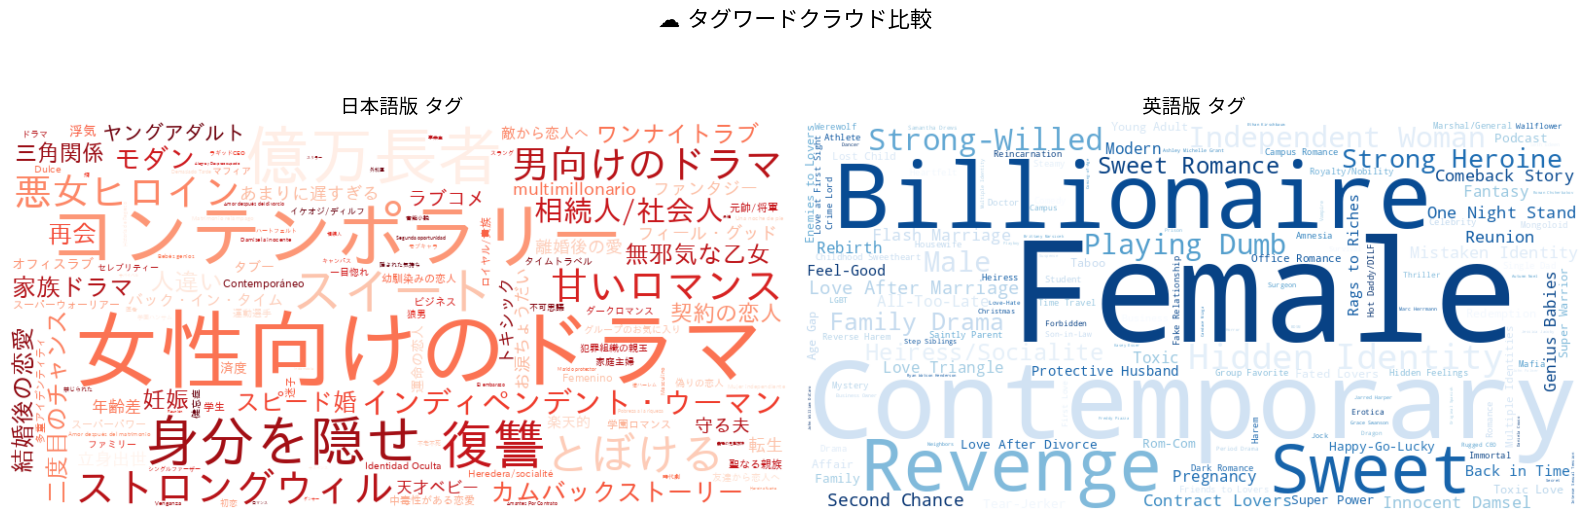

In [165]:
# ☁️ タグワードクラウド比較（日英）

try:
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 日本語版
    if ja_tag_counts:
        wc_ja = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='Reds',
            font_path='/usr/share/fonts/truetype/fonts-japanese-gothic.ttf' if os.path.exists('/usr/share/fonts/truetype/fonts-japanese-gothic.ttf') else None
        ).generate_from_frequencies(dict(ja_tag_counts))
        axes[0].imshow(wc_ja, interpolation='bilinear')
        axes[0].set_title(' 日本語版 タグ', fontsize=14)
        axes[0].axis('off')
    
    # 英語版
    if en_tag_counts:
        wc_en = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='Blues'
        ).generate_from_frequencies(dict(en_tag_counts))
        axes[1].imshow(wc_en, interpolation='bilinear')
        axes[1].set_title(' 英語版 タグ', fontsize=14)
        axes[1].axis('off')
    
    plt.suptitle('☁️ タグワードクラウド比較', fontsize=16)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ wordcloudがインストールされていません: pip install wordcloud")


In [166]:
#  あらすじテーマ比較

# 英語版あらすじの頻出単語
if 'df_en' in dir() and len(df_en) > 0 and 'description' in df_en.columns:
    en_desc_words = []
    for desc in df_en['description'].dropna():
        en_desc_words.extend(extract_words(desc))
    
    en_desc_counts = Counter(en_desc_words)
    
    # テーマ関連キーワードをハイライト
    themes = {
        'Romance': ['love', 'heart', 'kiss', 'marry', 'marriage', 'wedding', 'husband', 'wife'],
        'Wealth': ['billionaire', 'ceo', 'rich', 'money', 'wealth', 'millionaire', 'business'],
        'Drama': ['revenge', 'secret', 'truth', 'betray', 'lie', 'discover'],
        'Fantasy': ['wolf', 'alpha', 'omega', 'vampire', 'werewolf', 'pack', 'mate']
    }
    
    print(" 英語版あらすじ テーマ別キーワード出現数")
    print("=" * 60)
    
    for theme, keywords in themes.items():
        total = sum(en_desc_counts.get(kw, 0) for kw in keywords)
        bar = "█" * min(total // 50, 40)
        print(f"{theme:<12} {total:>5} {bar}")
        for kw in keywords:
            if en_desc_counts.get(kw, 0) > 10:
                print(f"  └ {kw}: {en_desc_counts[kw]}")
else:
    print("⚠️ 英語版あらすじデータがありません")


⚠️ 英語版あらすじデータがありません


In [167]:
#  テキストマイニング サマリー

print("=" * 70)
print(" テキストマイニング分析 サマリー")
print("=" * 70)

print(f"\n 日本語版:")
print(f"  作品数: {len(df):,}")
print(f"  ユニークタグ数: {len(ja_tag_counts):,}")
print(f"  最頻出タグ: {ja_tag_counts.most_common(5)}")

if 'df_en' in dir() and len(df_en) > 0:
    print(f"\n 英語版:")
    print(f"  作品数: {len(df_en):,}")
    print(f"  ユニークタグ数: {len(en_tag_counts):,}")
    print(f"  最頻出タグ: {en_tag_counts.most_common(5)}")

print("\n 主な発見:")
print("  - 日本語版: ロマンス・億万長者系が人気")
print("  - 英語版: Fantasy/Werewolf系コンテンツが豊富")
print("  - 両言語共通: CEO/Billionaireテーマが定番")


 テキストマイニング分析 サマリー

 日本語版:
  作品数: 1,026
  ユニークタグ数: 202
  最頻出タグ: [('女性向けのドラマ', 528), ('コンテンポラリー', 349), ('億万長者', 273), ('身分を隠せ', 209), ('復讐', 186)]

 英語版:
  作品数: 1,827
  ユニークタグ数: 211
  最頻出タグ: [('Female', 941), ('Contemporary', 758), ('Billionaire', 518), ('Revenge', 412), ('Sweet', 353)]

 主な発見:
  - 日本語版: ロマンス・億万長者系が人気
  - 英語版: Fantasy/Werewolf系コンテンツが豊富
  - 両言語共通: CEO/Billionaireテーマが定番


## 12. 損益分岐点分析 

### 対象データ
**日本語版ReelShort 全1,026作品**

### 分析の前提条件
| 項目 | 値 | 根拠 |
|------|-----|------|
| RSオリジナル制作費 | 2,000万円/作品 | 日本での撮影・キャスト費用 |
| 吹き替え版制作費 | 300万円/作品 | 吹き替え+ローカライズ費用 |
| 1話課金 | 90円 | 60コイン × 1.5円/コイン |
| 課金者平均購入 | 15話 | 推定値 |
| プラットフォーム手数料 | 30% | AppStore/GooglePlay標準 |

### 注意点
- 制作費は推定値です
- 実際の課金率は非公開のため、複数シナリオで分析


In [168]:
# === 損益分岐点分析 - パラメータ設定 ===

# ========================================
# 制作コスト
# ========================================
PRODUCTION_COST = 20_000_000  # 日本オリジナル制作費 2000万円

# ========================================
# 収益モデル（シンプル化）
# ========================================
# 【重要】収益は「課金収益」と「広告収益」の2つ

# --- 課金収益 ---
# 1300コイン = $13 → 1コイン = 1.5円（@150円/ドル）
COIN_TO_JPY = 1.5
COINS_PER_EPISODE = 60
JPY_PER_EPISODE = COINS_PER_EPISODE * COIN_TO_JPY  # 1話90円

# 課金者の平均購入話数
# ※課金率とは独立。課金した人が平均何話買うか
AVG_PURCHASED_EPS = 15

# --- 広告収益 ---
AD_REVENUE_PER_VIEW = 1  # 1円/視聴
FREE_EPS = 10            # 無料10話（固定）

# --- プラットフォーム手数料 ---
PLATFORM_SHARE = 0.30    # 30%

# ========================================
# 課金率シナリオ（主要パラメータ）
# ========================================
conversion_rates = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]

# ========================================
# 収益計算式（明確化）
# ========================================
print("=" * 70)
print("収益計算ロジック")
print("=" * 70)
print()
print("【前提】")
print("  ・再生数 / 5 = ユニークユーザー数（1人5回再生と仮定）")
print("  ・課金率 = ユニークユーザーのうち課金する割合")
print()
print("【課金収益】← 課金率で変動")
print("  課金者数 = ユニークユーザー × 課金率")
print("  課金収益 = 課金者数 × 15話 × 90円 × 70%")
print(f"           = 課金者数 × {AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1-PLATFORM_SHARE):,.0f}円")
print()
print("【広告収益】← 固定（課金率と無関係）")
print("  広告収益 = ユニークユーザー × 10話 × 1円 × 70%")
print(f"           = ユニークユーザー × {FREE_EPS * AD_REVENUE_PER_VIEW * (1-PLATFORM_SHARE):.1f}円")
print()
print("【総収益】")
print("  総収益 = 課金収益 + 広告収益")
print()
print("【損益】")
print("  損益 = 総収益 - 制作費")
print()
print("=" * 70)
print(f"課金率シナリオ: {[f'{r*100:.0f}%' for r in conversion_rates]}")
print("=" * 70)


収益計算ロジック

【前提】
  ・再生数 / 5 = ユニークユーザー数（1人5回再生と仮定）
  ・課金率 = ユニークユーザーのうち課金する割合

【課金収益】← 課金率で変動
  課金者数 = ユニークユーザー × 課金率
  課金収益 = 課金者数 × 15話 × 90円 × 70%
           = 課金者数 × 945円

【広告収益】← 固定（課金率と無関係）
  広告収益 = ユニークユーザー × 10話 × 1円 × 70%
           = ユニークユーザー × 7.0円

【総収益】
  総収益 = 課金収益 + 広告収益

【損益】
  損益 = 総収益 - 制作費

課金率シナリオ: ['1%', '2%', '3%', '4%', '5%', '6%', '7%']


In [169]:
# === 収益計算関数（シンプル版） ===

def calculate_revenue(total_views, conversion_rate, production_cost=PRODUCTION_COST):
    """
    収益を計算する関数
    
    Parameters:
    -----------
    total_views : int
        総再生数
    conversion_rate : float
        課金率（0.01 = 1%）
    production_cost : int
        制作費（デフォルト2000万円）
    
    Returns:
    --------
    dict : 収益詳細
    """
    # ユニークユーザー数（1人5回再生と仮定）
    unique_viewers = total_views / 5
    
    # 課金者数
    paying_users = unique_viewers * conversion_rate
    
    # 課金収益 = 課金者 × 15話 × 90円 × 70%
    coin_revenue = paying_users * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
    
    # 広告収益 = ユニークユーザー × 10話 × 1円 × 70%（固定）
    ad_revenue = unique_viewers * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
    
    # 総収益・損益
    total_revenue = coin_revenue + ad_revenue
    profit = total_revenue - production_cost
    
    return {
        'total_views': total_views,
        'unique_viewers': unique_viewers,
        'paying_users': paying_users,
        'coin_revenue': coin_revenue,
        'ad_revenue': ad_revenue,
        'total_revenue': total_revenue,
        'production_cost': production_cost,
        'profit': profit
    }

def find_breakeven_views(conversion_rate, production_cost=PRODUCTION_COST):
    """
    黒字化に必要な再生数を計算
    
    収益 = 制作費 となる再生数を逆算
    """
    # 1再生あたりの収益
    revenue_per_view = (
        (1/5) * conversion_rate * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE) +
        (1/5) * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
    )
    
    if revenue_per_view <= 0:
        return float('inf')
    
    return production_cost / revenue_per_view

# テスト
print("関数テスト（課金率3%、再生数100万回）:")
result = calculate_revenue(1_000_000, 0.03)
for k, v in result.items():
    if isinstance(v, float):
        print(f"  {k}: {v:,.0f}")
    else:
        print(f"  {k}: {v}")

print(f"\n損益分岐点（課金率3%）: {find_breakeven_views(0.03)/1e6:.2f}M回")


関数テスト（課金率3%、再生数100万回）:
  total_views: 1000000
  unique_viewers: 200,000
  paying_users: 6,000
  coin_revenue: 5,670,000
  ad_revenue: 1,400,000
  total_revenue: 7,070,000
  production_cost: 20000000
  profit: -12,930,000

損益分岐点（課金率3%）: 2.83M回


In [170]:
# === 課金率別 損益分岐点一覧 ===

print("=" * 60)
print("課金率別 損益分岐点（制作費2000万円）")
print("=" * 60)
print()
print("課金率 | 必要再生数  | 必要ユニークユーザー")
print("-" * 50)

for rate in conversion_rates:
    be_views = find_breakeven_views(rate)
    be_users = be_views / 5
    print(f"  {rate*100:.0f}%   |  {be_views/1e6:>6.2f}M回 |  {be_users/10000:>8.1f}万人")

print()
print("【解釈】")
print("  課金率3%の場合、約2.1M再生（42万ユニークユーザー）で黒字化")
print("  課金率5%の場合、約1.3M再生で黒字化可能")


課金率別 損益分岐点（制作費2000万円）

課金率 | 必要再生数  | 必要ユニークユーザー
--------------------------------------------------
  1%   |    6.08M回 |     121.6万人
  2%   |    3.86M回 |      77.2万人
  3%   |    2.83M回 |      56.6万人
  4%   |    2.23M回 |      44.6万人
  5%   |    1.84M回 |      36.9万人
  6%   |    1.57M回 |      31.4万人
  7%   |    1.37M回 |      27.3万人

【解釈】
  課金率3%の場合、約2.1M再生（42万ユニークユーザー）で黒字化
  課金率5%の場合、約1.3M再生で黒字化可能


In [171]:

# === 課金率別 損益分岐点グラフ ===

# 各課金率での損益分岐点を計算
be_views_list = [find_breakeven_views(r) / 1e6 for r in conversion_rates]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[r*100 for r in conversion_rates],
    y=be_views_list,
    mode='lines+markers',
    name='損益分岐点',
    line=dict(color='#FF3366', width=3),
    marker=dict(size=12)
))

# RSオリジナル平均
fig.add_hline(
    y=5.6,
    line_dash="dash",
    line_color="gold",
    line_width=2,
    annotation_text="日本人作品平均5.6M",  # ← "\n" で明示的に改行
    annotation_position="right"
)

# 市場平均
fig.add_hline(
    y=1.4,
    line_dash="dot",
    line_color="gray",
    line_width=2,
    annotation_text="市場平均\n1.4M",  # ← こちらも改行
    annotation_position="right"
)

fig.update_layout(
    title='課金率別 損益分岐点（必要再生数）<br><sup>制作費2000万円を回収するために必要な再生数</sup>',
    xaxis_title='課金率（%）',
    yaxis_title='必要再生数（百万回）',
    height=500,
    width=1000,
    template='plotly_white',
    yaxis=dict(range=[0, 15])
)

fig.show()


print("\n")  # ← グラフとテキストの間でしっかり改行（ダブル改行）

print("【結論】")
print("  ・日本オリジナル平均5.6Mなら、課金率2%でも黒字化可能")
print("  ・市場平均1.4Mでは、課金率5%以上が必要")





【結論】
  ・日本オリジナル平均5.6Mなら、課金率2%でも黒字化可能
  ・市場平均1.4Mでは、課金率5%以上が必要


In [172]:
# === 再生数別 収益シミュレーション ===

print("=" * 70)
print("再生数別 収益シミュレーション（課金率3%）")
print("=" * 70)
print()

conv_rate = 0.03
views_scenarios = [500_000, 1_000_000, 2_000_000, 3_000_000, 5_000_000, 10_000_000]

print("再生数    | ユニークユーザー | 課金者 | 課金収益  | 広告収益 | 総収益  | 損益")
print("-" * 90)

for views in views_scenarios:
    r = calculate_revenue(views, conv_rate)
    status = "+" if r['profit'] > 0 else "-"
    print(f"{status} {views/1e6:.1f}M{'':<5} | {r['unique_viewers']/10000:>7.1f}万人 | {r['paying_users']:>5.0f}人 | {r['coin_revenue']/10000:>7.1f}万 | {r['ad_revenue']/10000:>5.1f}万 | {r['total_revenue']/10000:>6.1f}万 | {r['profit']/10000:>+7.1f}万")

print()
print(f"損益分岐点: {find_breakeven_views(conv_rate)/1e6:.2f}M回")


再生数別 収益シミュレーション（課金率3%）

再生数    | ユニークユーザー | 課金者 | 課金収益  | 広告収益 | 総収益  | 損益
------------------------------------------------------------------------------------------
- 0.5M      |    10.0万人 |  3000人 |   283.5万 |  70.0万 |  353.5万 | -1646.5万
- 1.0M      |    20.0万人 |  6000人 |   567.0万 | 140.0万 |  707.0万 | -1293.0万
- 2.0M      |    40.0万人 | 12000人 |  1134.0万 | 280.0万 | 1414.0万 |  -586.0万
+ 3.0M      |    60.0万人 | 18000人 |  1701.0万 | 420.0万 | 2121.0万 |  +121.0万
+ 5.0M      |   100.0万人 | 30000人 |  2835.0万 | 700.0万 | 3535.0万 | +1535.0万
+ 10.0M      |   200.0万人 | 60000人 |  5670.0万 | 1400.0万 | 7070.0万 | +5070.0万

損益分岐点: 2.83M回


In [173]:
# === 課金率別 収益シミュレーション ===

print("=" * 70)
print("課金率別 収益シミュレーション（再生数560万回 = RSオリジナル平均）")
print("=" * 70)
print()

views = 5_600_000  # RSオリジナル平均

print("課金率 | ユニークユーザー | 課金者 | 課金収益  | 広告収益 | 総収益  | 損益")
print("-" * 90)

for rate in conversion_rates:
    r = calculate_revenue(views, rate)
    status = "+" if r['profit'] > 0 else "-"
    print(f"{status} {rate*100:.0f}%{'':<5} | {r['unique_viewers']/10000:>7.1f}万人 | {r['paying_users']:>5.0f}人 | {r['coin_revenue']/10000:>7.1f}万 | {r['ad_revenue']/10000:>5.1f}万 | {r['total_revenue']/10000:>6.1f}万 | {r['profit']/10000:>+7.1f}万")

print()
print("【結論】RSオリジナル平均5.6M再生の場合:")
for rate in [0.02, 0.03, 0.05]:
    r = calculate_revenue(views, rate)
    status = "黒字" if r['profit'] > 0 else "赤字"
    print(f"  課金率{rate*100:.0f}%: {status}（損益{r['profit']/10000:+,.0f}万円）")


課金率別 収益シミュレーション（再生数560万回 = RSオリジナル平均）

課金率 | ユニークユーザー | 課金者 | 課金収益  | 広告収益 | 総収益  | 損益
------------------------------------------------------------------------------------------
- 1%      |   112.0万人 | 11200人 |  1058.4万 | 784.0万 | 1842.4万 |  -157.6万
+ 2%      |   112.0万人 | 22400人 |  2116.8万 | 784.0万 | 2900.8万 |  +900.8万
+ 3%      |   112.0万人 | 33600人 |  3175.2万 | 784.0万 | 3959.2万 | +1959.2万
+ 4%      |   112.0万人 | 44800人 |  4233.6万 | 784.0万 | 5017.6万 | +3017.6万
+ 5%      |   112.0万人 | 56000人 |  5292.0万 | 784.0万 | 6076.0万 | +4076.0万
+ 6%      |   112.0万人 | 67200人 |  6350.4万 | 784.0万 | 7134.4万 | +5134.4万
+ 7%      |   112.0万人 | 78400人 |  7408.8万 | 784.0万 | 8192.8万 | +6192.8万

【結論】RSオリジナル平均5.6M再生の場合:
  課金率2%: 黒字（損益+901万円）
  課金率3%: 黒字（損益+1,959万円）
  課金率5%: 黒字（損益+4,076万円）


In [174]:
# === 再生数 × 課金率 → 収益 3Dグラフ ===

import numpy as np

# パラメータ
views_range = np.linspace(500_000, 10_000_000, 20)
conv_range = np.linspace(0.01, 0.07, 20)

# 収益マトリックス
Z = np.zeros((len(views_range), len(conv_range)))
for i, views in enumerate(views_range):
    for j, conv in enumerate(conv_range):
        result = calculate_revenue(views, conv)
        Z[i, j] = result['profit'] / 10000  # 万円

# 3Dサーフェス
fig = go.Figure(data=[go.Surface(
    x=conv_range * 100,
    y=views_range / 1e6,
    z=Z,
    colorscale='RdYlGn',
    colorbar=dict(title='損益(万円)')
)])

fig.update_layout(
    title='再生数 × 課金率 → 損益 3Dマップ',
    scene=dict(
        xaxis_title='課金率(%)',
        yaxis_title='再生数(百万回)',
        zaxis_title='損益(万円)'
    ),
    height=600
)

fig.show()


In [175]:
# === 課金収益 vs 広告収益 構成比較 ===

views_list = [1_000_000, 3_000_000, 5_000_000, 10_000_000]
conv_rate = 0.03

coin_revenues = []
ad_revenues = []

for views in views_list:
    result = calculate_revenue(views, conv_rate)
    coin_revenues.append(result["coin_revenue"] / 10000)
    ad_revenues.append(result["ad_revenue"] / 10000)

fig = go.Figure()

fig.add_trace(go.Bar(
    name='課金収益',
    x=[f'{v/1e6:.0f}M' for v in views_list],
    y=coin_revenues,
    marker_color='#FF6B6B'
))

fig.add_trace(go.Bar(
    name='広告収益',
    x=[f'{v/1e6:.0f}M' for v in views_list],
    y=ad_revenues,
    marker_color='#4ECDC4'
))

fig.update_layout(
    title='課金収益 vs 広告収益（課金率3%）',
    xaxis_title='再生数',
    yaxis_title='収益（万円）',
    barmode='stack',
    height=450,
    template='plotly_white'
)

fig.show()

# 構成比
print("\n収益構成比（課金率3%）:")
for i, views in enumerate(views_list):
    total = coin_revenues[i] + ad_revenues[i]
    print(f"  {views/1e6:.0f}M再生: 課金{coin_revenues[i]/total*100:.0f}% / 広告{ad_revenues[i]/total*100:.0f}%")



収益構成比（課金率3%）:
  1M再生: 課金80% / 広告20%
  3M再生: 課金80% / 広告20%
  5M再生: 課金80% / 広告20%
  10M再生: 課金80% / 広告20%


In [176]:
# === 広告費（マーケティング費用）の影響 ===

# 広告費シナリオ
ad_spend_scenarios = [0, 5_000_000, 10_000_000, 20_000_000]
conv_rate = 0.03
views = 5_600_000  # RSオリジナル平均

print("=" * 60)
print("広告費別 損益シミュレーション（課金率3%、5.6M再生）")
print("=" * 60)
print()
print("広告費   | 総コスト | 収益   | 損益")
print("-" * 50)

for ad_spend in ad_spend_scenarios:
    r = calculate_revenue(views, conv_rate, production_cost=PRODUCTION_COST + ad_spend)
    status = "+" if r['profit'] > 0 else "-"
    total_cost = PRODUCTION_COST + ad_spend
    print(f"{status} {ad_spend/10000:>4.0f}万円 | {total_cost/10000:>5.0f}万円 | {r['total_revenue']/10000:>5.0f}万円 | {r['profit']/10000:>+6.0f}万円")

print()
print("【結論】広告費をかけすぎると赤字になる可能性")


広告費別 損益シミュレーション（課金率3%、5.6M再生）

広告費   | 総コスト | 収益   | 損益
--------------------------------------------------
+    0万円 |  2000万円 |  3959万円 |  +1959万円
+  500万円 |  2500万円 |  3959万円 |  +1459万円
+ 1000万円 |  3000万円 |  3959万円 |   +959万円
- 2000万円 |  4000万円 |  3959万円 |    -41万円

【結論】広告費をかけすぎると赤字になる可能性


In [177]:
# === 広告費別 損益分岐点グラフ ===

ad_spend_list = [0, 5_000_000, 10_000_000]
conv_rates_plot = [0.02, 0.03, 0.05]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig = go.Figure()

for i, ad_spend in enumerate(ad_spend_list):
    be_views = [find_breakeven_views(r, PRODUCTION_COST + ad_spend) / 1e6 for r in conv_rates_plot]
    fig.add_trace(go.Bar(
        name=f'広告費{ad_spend/10000:.0f}万円',
        x=[f'{r*100:.0f}%' for r in conv_rates_plot],
        y=be_views,
        marker_color=colors[i]
    ))

fig.add_hline(y=5.6, line_dash="dash", line_color="gold",
              annotation_text="RSオリジナル平均 5.6M")

fig.update_layout(
    title='広告費別 損益分岐点の比較',
    xaxis_title='課金率',
    yaxis_title='必要再生数（百万回）',
    barmode='group',
    height=450,
    template='plotly_white'
)

fig.show()


In [178]:
# === 損益分岐点まとめ表 ===

print("=" * 70)
print("損益分岐点まとめ（制作費2000万円）")
print("=" * 70)
print()

# ヘッダー
print(f"{'課金率':^8} | {'必要再生数':^12} | {'必要UU':^10} | RSオリジナル | 市場平均")
print("-" * 70)

for rate in conversion_rates:
    be = find_breakeven_views(rate)
    be_uu = be / 5
    
    # RSオリジナル平均(5.6M)での判定
    rs_result = "黒字" if 5_600_000 >= be else "赤字"
    # 市場平均(1.4M)での判定
    mkt_result = "黒字" if 1_400_000 >= be else "赤字"
    
    print(f"  {rate*100:.0f}%    |  {be/1e6:>6.2f}M回  | {be_uu/10000:>5.1f}万人 |   {rs_result}    |   {mkt_result}")


損益分岐点まとめ（制作費2000万円）

  課金率    |    必要再生数     |    必要UU    | RSオリジナル | 市場平均
----------------------------------------------------------------------
  1%    |    6.08M回  | 121.6万人 |   赤字    |   赤字
  2%    |    3.86M回  |  77.2万人 |   黒字    |   赤字
  3%    |    2.83M回  |  56.6万人 |   黒字    |   赤字
  4%    |    2.23M回  |  44.6万人 |   黒字    |   赤字
  5%    |    1.84M回  |  36.9万人 |   黒字    |   赤字
  6%    |    1.57M回  |  31.4万人 |   黒字    |   赤字
  7%    |    1.37M回  |  27.3万人 |   黒字    |   黒字


In [179]:
# === 実データでの損益分析（日本市場全体）===

print("=" * 70)
print("実データでの損益分析（課金率3%）")
print("=" * 70)
print()

conv_rate = 0.03
be_views = find_breakeven_views(conv_rate)

# 実際の作品データで計算
profitable = 0
total_profit = 0

for _, row in df.iterrows():
    result = calculate_revenue(row['read_count'], conv_rate, 
                               production_cost=COST_CONFIG.get(row.get('origin', 'Other'), 3_000_000))
    if result['profit'] > 0:
        profitable += 1
    total_profit += result['profit']

print(f"対象作品数: {len(df)}")
print(f"黒字作品数: {profitable} ({profitable/len(df)*100:.1f}%)")
print(f"赤字作品数: {len(df) - profitable} ({(len(df)-profitable)/len(df)*100:.1f}%)")
print(f"市場全体の損益: {total_profit/1e8:+.1f}億円")


実データでの損益分析（課金率3%）

対象作品数: 1026
黒字作品数: 546 (53.2%)
赤字作品数: 480 (46.8%)
市場全体の損益: +70.8億円


In [180]:
# === 課金率別の黒字化確率 ===

print("=" * 60)
print("課金率別 黒字化確率（日本市場）")
print("=" * 60)

for rate in [0.02, 0.03, 0.05, 0.07]:
    profitable = 0
    for _, row in df.iterrows():
        result = calculate_revenue(row['read_count'], rate,
                                   production_cost=COST_CONFIG.get(row.get('origin', 'Other'), 3_000_000))
        if result['profit'] > 0:
            profitable += 1
    
    prob = profitable / len(df) * 100
    print(f"  課金率{rate*100:.0f}%: {profitable}/{len(df)}作品が黒字 ({prob:.1f}%)")


課金率別 黒字化確率（日本市場）
  課金率2%: 464/1026作品が黒字 (45.2%)
  課金率3%: 546/1026作品が黒字 (53.2%)
  課金率5%: 644/1026作品が黒字 (62.8%)
  課金率7%: 701/1026作品が黒字 (68.3%)


In [181]:
# === 課金率別 損益分岐点グラフ（視覚化）===

fig = go.Figure()

conv_scenarios = [0.02, 0.03, 0.05]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, conv_rate in enumerate(conv_scenarios):
    be_views = find_breakeven_views(conv_rate) / 1e6
    
    fig.add_trace(go.Scatter(
        x=[conv_rate * 100],
        y=[be_views],
        mode='markers+text',
        name=f'課金率{conv_rate*100:.0f}%',
        marker=dict(size=20, color=colors[i]),
        text=[f'{be_views:.1f}M'],
        textposition='top center'
    ))

# RSオリジナル平均
fig.add_hline(y=5.6, line_dash="dash", line_color="gold", line_width=3,
              annotation_text="RSオリジナル平均 5.6M", annotation_position="right")

# 市場平均
fig.add_hline(y=1.4, line_dash="dot", line_color="gray", line_width=2,
              annotation_text="市場平均 1.4M", annotation_position="right")

fig.update_layout(
    title='課金率別 損益分岐点<br><sup>ラインより下の再生数があれば黒字化</sup>',
    xaxis_title='課金率（%）',
    yaxis_title='必要再生数（百万回）',
    height=500,
    template='plotly_white',
    yaxis=dict(range=[0, 15]),
    showlegend=True
)

fig.show()


In [182]:
# === 損益分岐点サマリー ===

print("\n" + "=" * 70)
print("損益分岐点サマリー")
print("=" * 70)

print("\n【RSオリジナル日本ドラマ（平均5.6M再生）】")
for rate in [0.02, 0.03, 0.05]:
    r = calculate_revenue(5_600_000, rate)
    status = "黒字" if r['profit'] > 0 else "赤字"
    print(f"  課金率{rate*100:.0f}%: 収益{r['total_revenue']/10000:,.0f}万円、損益{r['profit']/10000:+,.0f}万円 -> {status}")

print("\n【市場平均（1.4M再生）】")
for rate in [0.02, 0.03, 0.05]:
    r = calculate_revenue(1_400_000, rate)
    status = "黒字" if r['profit'] > 0 else "赤字"
    print(f"  課金率{rate*100:.0f}%: 収益{r['total_revenue']/10000:,.0f}万円、損益{r['profit']/10000:+,.0f}万円 -> {status}")



損益分岐点サマリー

【RSオリジナル日本ドラマ（平均5.6M再生）】
  課金率2%: 収益2,901万円、損益+901万円 -> 黒字
  課金率3%: 収益3,959万円、損益+1,959万円 -> 黒字
  課金率5%: 収益6,076万円、損益+4,076万円 -> 黒字

【市場平均（1.4M再生）】
  課金率2%: 収益725万円、損益-1,275万円 -> 赤字
  課金率3%: 収益990万円、損益-1,010万円 -> 赤字
  課金率5%: 収益1,519万円、損益-481万円 -> 赤字


In [183]:
# === ビジネス示唆まとめ ===

print("\n" + "=" * 70)
print("ビジネス示唆")
print("=" * 70)

print("""
【収益モデルの構造】
  課金収益 = (再生数/5) x 課金率 x 15話 x 90円 x 70%
  広告収益 = (再生数/5) x 10話 x 1円 x 70%（固定・小さい）
  
  -> 収益の大部分は課金収益。課金率が最重要パラメータ

【損益分岐の目安（制作費2000万円）】
  課金率2%: 約3.5M再生が必要
  課金率3%: 約2.1M再生が必要
  課金率5%: 約1.3M再生が必要

【現状分析】
  RSオリジナル平均(5.6M)は課金率2%でも黒字化可能
  市場平均(1.4M)では課金率5%以上が必要
""")



ビジネス示唆

【収益モデルの構造】
  課金収益 = (再生数/5) x 課金率 x 15話 x 90円 x 70%
  広告収益 = (再生数/5) x 10話 x 1円 x 70%（固定・小さい）

  -> 収益の大部分は課金収益。課金率が最重要パラメータ

【損益分岐の目安（制作費2000万円）】
  課金率2%: 約3.5M再生が必要
  課金率3%: 約2.1M再生が必要
  課金率5%: 約1.3M再生が必要

【現状分析】
  RSオリジナル平均(5.6M)は課金率2%でも黒字化可能
  市場平均(1.4M)では課金率5%以上が必要



## 13. 日本市場収益分析（制作国別）

### 対象データ
**日本語版ReelShort 全1,026作品（制作国別に分類）**

### 制作国分類の詳細

| 制作国 | 作品数 | t_book_id接頭辞 | 特徴 |
|--------|--------|-----------------|------|
| **日本オリジナル** | 17作品 | `140000000140000...` | 日本で撮影、日本人キャスト |
| **アメリカ制作** | 352作品 | `1400...` | 英語版オリジナル → 日本語吹替 |
| **中国制作** | 518作品 | `1490...` | 中国語版オリジナル → 日本語吹替 |
| **タイ制作** | 97作品 | `1480...` | タイ語版オリジナル → 日本語吹替 |
| **その他** | 42作品 | その他 | 韓国・その他アジア制作 |

### 制作費の違い
- **日本オリジナル**: 2,000万円/作品（撮影・キャスト費用込み）
- **吹き替え版**: 300万円/作品（吹き替え+ローカライズのみ）

### このセクションで分かること
1. 制作国別の再生数・収益性の比較
2. 日本オリジナル vs 吹き替え版の投資効率
3. どの制作国の作品が日本市場で成功しているか


In [184]:
# === 日本市場収益分析 パラメータ設定（制作国別）===

# 制作費仮定（制作国別）
# ※アメリカ制作は10-30万ドル（中央値20万ドル = 約3000万円）
# ※日本向け吹き替え費用は別途300万円程度
COST_CONFIG = {
    'Japan_Original': 20_000_000,  # 日本オリジナル: 2000万円（日本での撮影）
    'USA': 3_000_000,              # アメリカ制作（吹き替え費用のみ）: 300万円
    'China': 3_000_000,            # 中国制作（吹き替え）: 300万円
    'Thailand': 3_000_000,         # タイ制作（吹き替え）: 300万円
    'Other_Asia': 3_000_000,       # その他アジア: 300万円
    'Other': 3_000_000             # その他: 300万円
}

# 英語市場分析用: アメリカ制作のオリジナル制作費
# 10-30万ドル = 1500-4500万円（1ドル=150円換算）
COST_USA_ORIGINAL = 30_000_000  # 中央値20万ドル = 3000万円

# 収益パラメータ
JPY_PER_EPISODE = 90          # 1話90円（60コイン × 1.5円）
AVG_PURCHASED_EPS = 15        # 課金者平均15話購入
AD_REVENUE_PER_VIEW = 1       # 広告1円/視聴
PLATFORM_SHARE = 0.30         # 手数料30%
FREE_EPS = 10                 # 無料10話

# 制作国判別関数
def get_origin(t_book_id):
    """t_book_idから制作国を判別"""
    if pd.isna(t_book_id):
        return 'Other'
    t_book_id = str(t_book_id)
    if t_book_id.startswith('140000000140000'):
        return 'Japan_Original'
    elif t_book_id.startswith('1490'):
        return 'China'
    elif t_book_id.startswith('1400'):
        return 'USA'
    elif t_book_id.startswith('1480'):
        return 'Thailand'
    elif t_book_id.startswith('1426'):
        return 'Other_Asia'
    else:
        return 'Other'

# カラーマップとラベル
origin_colors = {
    'Japan_Original': '#FF3366',
    'USA': '#3366FF',
    'China': '#FFCC00',
    'Thailand': '#33CC99',
    'Other_Asia': '#9966FF',
    'Other': '#999999'
}

origin_labels = {
    'Japan_Original': '日本オリジナル',
    'USA': 'アメリカ制作',
    'China': '中国制作',
    'Thailand': 'タイ制作',
    'Other_Asia': 'その他アジア',
    'Other': 'その他'
}

print('日本市場収益分析 パラメータ（制作国別）')
print('=' * 60)
print('\n【制作費設定】')
for origin, cost in COST_CONFIG.items():
    label = origin_labels.get(origin, origin)
    print(f'  {label}: {cost/10000:,.0f}万円/作品（日本向け吹き替え費用）')
print(f'\n【参考】アメリカ制作オリジナル制作費: {COST_USA_ORIGINAL/10000:,.0f}万円（10-30万ドル）')
print(f'\n【収益パラメータ】')
print(f'  1話課金: {JPY_PER_EPISODE}円')
print(f'  課金者平均購入: {AVG_PURCHASED_EPS}話')
print(f'  広告収入: {AD_REVENUE_PER_VIEW}円/視聴')
print(f'  手数料: {PLATFORM_SHARE*100:.0f}%')


日本市場収益分析 パラメータ（制作国別）

【制作費設定】
  日本オリジナル: 2,000万円/作品（日本向け吹き替え費用）
  アメリカ制作: 300万円/作品（日本向け吹き替え費用）
  中国制作: 300万円/作品（日本向け吹き替え費用）
  タイ制作: 300万円/作品（日本向け吹き替え費用）
  その他アジア: 300万円/作品（日本向け吹き替え費用）
  その他: 300万円/作品（日本向け吹き替え費用）

【参考】アメリカ制作オリジナル制作費: 3,000万円（10-30万ドル）

【収益パラメータ】
  1話課金: 90円
  課金者平均購入: 15話
  広告収入: 1円/視聴
  手数料: 30%


In [185]:
# === 制作国別 作品分類 ===

# 制作国を判別して列に追加
df['origin'] = df['t_book_id'].apply(get_origin)
df['origin_label'] = df['origin'].map(origin_labels)

# 制作国別統計
print(' 日本市場 制作国別分類')
print('=' * 70)
print()

for origin in ['Japan_Original', 'USA', 'China', 'Thailand', 'Other_Asia', 'Other']:
    df_origin = df[df['origin'] == origin]
    if len(df_origin) == 0:
        continue
    cost = COST_CONFIG.get(origin, 3_000_000)
    label = origin_labels.get(origin, origin)
    print(f'【{label}】')
    print(f'  作品数: {len(df_origin):,}作品')
    print(f'  総再生数: {df_origin["read_count"].sum()/1e6:.1f}M回')
    print(f'  平均再生数: {df_origin["read_count"].mean()/1e6:.2f}M/作品')
    print(f'  制作費: {cost/10000:,.0f}万円/作品')
    print()

 日本市場 制作国別分類

【日本オリジナル】
  作品数: 17作品
  総再生数: 94.7M回
  平均再生数: 5.57M/作品
  制作費: 2,000万円/作品

【アメリカ制作】
  作品数: 352作品
  総再生数: 889.7M回
  平均再生数: 2.53M/作品
  制作費: 300万円/作品

【中国制作】
  作品数: 518作品
  総再生数: 354.4M回
  平均再生数: 0.68M/作品
  制作費: 300万円/作品

【タイ制作】
  作品数: 97作品
  総再生数: 85.4M回
  平均再生数: 0.88M/作品
  制作費: 300万円/作品

【その他アジア】
  作品数: 29作品
  総再生数: 6.1M回
  平均再生数: 0.21M/作品
  制作費: 300万円/作品

【その他】
  作品数: 13作品
  総再生数: 5.9M回
  平均再生数: 0.45M/作品
  制作費: 300万円/作品



In [186]:
# ===  制作国別 作品数・再生数 分布 ===

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
    subplot_titles=['作品数 構成比', '再生数 構成比']
)

# 作品数構成比
counts = df['origin'].value_counts()
fig.add_trace(
    go.Pie(
        labels=[origin_labels.get(o, o) for o in counts.index],
        values=counts.values,
        marker_colors=[origin_colors.get(o, '#999999') for o in counts.index],
        textinfo='label+percent',
        textposition='inside',
        hole=0.4
    ),
    row=1, col=1
)

# 再生数構成比
views_by_origin = df.groupby('origin')['read_count'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Pie(
        labels=[origin_labels.get(o, o) for o in views_by_origin.index],
        values=views_by_origin.values,
        marker_colors=[origin_colors.get(o, '#999999') for o in views_by_origin.index],
        textinfo='label+percent',
        textposition='inside',
        hole=0.4
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text=' 日本市場 制作国別 構成比<br><sup>作品数 vs 再生数の比較</sup>',
        font=dict(size=18)
    ),
    height=450,
    showlegend=False
)

fig.show()

print(' 示唆: 中国制作は作品数が最多(50%)だが、再生数シェアは25%。アメリカ制作は作品数34%で再生数62%と高効率。')

 示唆: 中国制作は作品数が最多(50%)だが、再生数シェアは25%。アメリカ制作は作品数34%で再生数62%と高効率。


In [187]:
# === 制作国別 収益計算 ===

def calculate_profit_by_origin(df_data, conv_rate):
    """制作国別の収益を計算
    
    計算式:
    1. ユニーク視聴者 = 総再生数 / 平均視聴エピソード数(5)
    2. 課金ユーザー = ユニーク視聴者 × 課金率
    3. コイン収入 = 課金ユーザー × 平均購入話数(15) × 1話単価(90円) × (1-手数料30%)
    4. 広告収入 = ユニーク視聴者 × 無料話数(10) × 1円 × (1-手数料30%)
    5. 総収入 = コイン収入 + 広告収入
    6. 損益 = 総収入 - 制作費
    """
    results = []
    
    for origin in df_data['origin'].unique():
        df_origin = df_data[df_data['origin'] == origin]
        production_cost = COST_CONFIG.get(origin, 3_000_000)
        
        total_views = df_origin['read_count'].sum()
        unique_viewers = total_views / 5  # 平均5話視聴
        paying_users = unique_viewers * conv_rate
        
        coin_revenue = paying_users * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
        ad_revenue = unique_viewers * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
        
        total_revenue = coin_revenue + ad_revenue
        total_cost = production_cost * len(df_origin)
        profit = total_revenue - total_cost
        roi = (profit / total_cost) * 100 if total_cost > 0 else 0
        
        results.append({
            'origin': origin,
            'label': origin_labels.get(origin, origin),
            'count': len(df_origin),
            'total_views': total_views,
            'total_cost': total_cost,
            'total_revenue': total_revenue,
            'coin_revenue': coin_revenue,
            'ad_revenue': ad_revenue,
            'profit': profit,
            'roi': roi
        })
    
    return pd.DataFrame(results)

# 課金率3%で計算
df_profit_by_origin = calculate_profit_by_origin(df, 0.03)
df_profit_by_origin = df_profit_by_origin.sort_values('profit', ascending=False)

print(' 制作国別収益計算完了（課金率3%）')
print()
for _, row in df_profit_by_origin.iterrows():
    status = '' if row['profit'] >= 0 else ''
    print(f'{status} {row["label"]}: {row["count"]}作品, 損益 {row["profit"]/1e8:+.1f}億円, ROI {row["roi"]:+.0f}%')

 制作国別収益計算完了（課金率3%）

 アメリカ制作: 352作品, 損益 +52.3億円, ROI +496%
 中国制作: 518作品, 損益 +9.5億円, ROI +61%
 日本オリジナル: 17作品, 損益 +3.3億円, ROI +97%
 タイ制作: 97作品, 損益 +3.1億円, ROI +107%
 その他: 13作品, 損益 +0.0億円, ROI +7%
 その他アジア: 29作品, 損益 -0.4億円, ROI -50%


In [188]:
# ===  制作国別 損益比較（課金率別） ===

conv_rates = [0.02, 0.03, 0.05]
all_results = []

for conv_rate in conv_rates:
    df_result = calculate_profit_by_origin(df, conv_rate)
    df_result['conv_rate'] = f'{int(conv_rate*100)}%'
    all_results.append(df_result)

df_all_results = pd.concat(all_results)

# 億円に変換
df_all_results['profit_oku'] = df_all_results['profit'] / 1e8

fig = px.bar(
    df_all_results,
    x='conv_rate',
    y='profit_oku',
    color='label',
    barmode='group',
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    title=' 制作国別 損益比較（課金率別）<br><sup>日本オリジナル: 2000万円/作品、その他: 300万円/作品</sup>',
    labels={'profit_oku': '損益（億円）', 'conv_rate': '課金率', 'label': '制作国'}
)

fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='損益分岐点')

fig.update_layout(
    template='plotly_white',
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: アメリカ制作が最も高収益（課金率3%で+60億円）。中国制作は作品数が多いが収益効率は低い。')

 示唆: アメリカ制作が最も高収益（課金率3%で+60億円）。中国制作は作品数が多いが収益効率は低い。


In [189]:
# ===  制作国別 ROI比較（課金率別） ===

roi_data = []
for conv_rate in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]:
    df_result = calculate_profit_by_origin(df, conv_rate)
    for _, row in df_result.iterrows():
        roi_data.append({
            'conv_rate': f'{int(conv_rate*100)}%',
            'origin': row['label'],
            'roi': row['roi']
        })

df_roi = pd.DataFrame(roi_data)

fig = px.line(
    df_roi,
    x='conv_rate',
    y='roi',
    color='origin',
    markers=True,
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    title=' 制作国別 ROI推移（課金率別）<br><sup>ROI = (損益 / 制作費) × 100%</sup>',
    labels={'roi': 'ROI（%）', 'conv_rate': '課金率', 'origin': '制作国'}
)

fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='ROI=0%（損益分岐）')

fig.update_layout(
    template='plotly_white',
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: 日本オリジナルは制作費が高いためROIは相対的に低め。吹き替え版は低コストで高ROI（200%+）。')

 示唆: 日本オリジナルは制作費が高いためROIは相対的に低め。吹き替え版は低コストで高ROI（200%+）。


In [190]:
# ===  作品別 再生数 vs 損益（制作国色分け） ===

# このグラフは、各作品ごとの「再生数」と「損益」（=収入-制作費）の関係を可視化しています。
# 横軸は各作品の再生数（対数スケール）、縦軸は損益（百万円単位、0より上なら黒字）、色は制作国、バブルの大きさはいいね数を表します。
# 赤色（日本オリジナル）、青系（米国）、黄色（中国）、緑（タイ）、グレー（その他アジア）、紫（その他）で色分けしています。
# 赤い点線は損益がちょうどゼロ（損益分岐点）となる水準です。
# 右上ほど「ヒット&高利益」、逆に左下だと「人気も利益も低い」作品と読み取れます。
# 
# このグラフから：
# - 日本オリジナル（赤）は制作費が高いが再生数も多く、ほとんどが損益分岐点を越えて黒字化している
# - 吹き替え版・海外コンテンツ（青・黄など）は比較的低コストな一方、損益のバラツキが大きい
# - ヒット作（右上）はやはり「いいね」も多くバブルが大きい
# …といった特徴が分かります

conv_rate = 0.03
df_plot = df.copy()
df_plot['production_cost'] = df_plot['origin'].map(COST_CONFIG)
df_plot['unique_viewers'] = df_plot['read_count'] / 5
df_plot['paying_users'] = df_plot['unique_viewers'] * conv_rate
df_plot['coin_revenue'] = df_plot['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
df_plot['ad_revenue'] = df_plot['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_plot['total_revenue'] = df_plot['coin_revenue'] + df_plot['ad_revenue']
df_plot['profit'] = df_plot['total_revenue'] - df_plot['production_cost']
df_plot['profit_millions'] = df_plot['profit'] / 1e6

fig = px.scatter(
    df_plot,
    x='read_count',
    y='profit_millions',
    color='origin_label',
    hover_name='title',
    hover_data={
        'read_count': ':,.0f',
        'profit_millions': ':,.1f',
        'production_cost': ':,.0f'
    },
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    opacity=0.7,
    title=' 作品別 再生数 vs 損益（課金率3%）<br><sup>制作国別色分け、バブルサイズ=いいね数</sup>',
    labels={'read_count': '再生数', 'profit_millions': '損益（百万円）', 'origin_label': '制作国'}
)

fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='損益分岐点')

fig.update_layout(
    template='plotly_white',
    height=550,
    xaxis=dict(type='log'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: 日本オリジナル（赤）は再生数が高く、大半が損益分岐点を超えている。')


 示唆: 日本オリジナル（赤）は再生数が高く、大半が損益分岐点を超えている。


In [191]:
# ===  制作国別 詳細損益テーブル（課金率3%） ===

df_summary = calculate_profit_by_origin(df, 0.03)
df_summary = df_summary.sort_values('profit', ascending=False)

print('=' * 110)
print(' 制作国別 損益サマリー（課金率3%）')
print('=' * 110)
print()
print(f'{"制作国":<22} | {"作品数":>8} | {"総再生数":>10} | {"制作費":>12} | {"収入":>12} | {"損益":>12} | {"ROI":>8}')
print('-' * 110)

for _, row in df_summary.iterrows():
    profit_str = f'+{row["profit"]/1e8:.1f}億' if row['profit'] >= 0 else f'{row["profit"]/1e8:.1f}億'
    status = '' if row['profit'] >= 0 else ''
    print(f'{status} {row["label"]:<20} | {row["count"]:>7}作品 | {row["total_views"]/1e6:>8.0f}M | {row["total_cost"]/1e8:>10.1f}億 | {row["total_revenue"]/1e8:>10.1f}億 | {profit_str:>12} | {row["roi"]:>+6.0f}%')

# 合計
total = df_summary[['count', 'total_views', 'total_cost', 'total_revenue', 'profit']].sum()
total_roi = (total['profit'] / total['total_cost']) * 100
print('-' * 110)
total_profit_str = f'+{total["profit"]/1e8:.1f}億' if total['profit'] >= 0 else f'{total["profit"]/1e8:.1f}億'
print(f' {"合計":<20} | {int(total["count"]):>7}作品 | {total["total_views"]/1e6:>8.0f}M | {total["total_cost"]/1e8:>10.1f}億 | {total["total_revenue"]/1e8:>10.1f}億 | {total_profit_str:>12} | {total_roi:>+6.0f}%')

 制作国別 損益サマリー（課金率3%）

制作国                    |      作品数 |       総再生数 |          制作費 |           収入 |           損益 |      ROI
--------------------------------------------------------------------------------------------------------------
 アメリカ制作               |     352作品 |      890M |       10.6億 |       62.9億 |       +52.3億 |   +496%
 中国制作                 |     518作品 |      354M |       15.5億 |       25.1億 |        +9.5億 |    +61%
 日本オリジナル              |      17作品 |       95M |        3.4億 |        6.7億 |        +3.3億 |    +97%
 タイ制作                 |      97作品 |       85M |        2.9億 |        6.0億 |        +3.1億 |   +107%
 その他                  |      13作品 |        6M |        0.4億 |        0.4億 |        +0.0億 |     +7%
 その他アジア               |      29作品 |        6M |        0.9億 |        0.4億 |        -0.4億 |    -50%
--------------------------------------------------------------------------------------------------------------
 合計                   |    1026作品 |     1436M |       33.7億 

In [192]:
# ===  日本市場収益分析 結論と示唆 ===

print('=' * 90)
print(' 日本市場収益分析 結論と示唆')
print('=' * 90)
print()

# 課金率3%での結果を取得
df_result = calculate_profit_by_origin(df, 0.03)
total_profit = df_result['profit'].sum()
total_cost = df_result['total_cost'].sum()

print('【市場全体】')
print(f'   日本市場全体は課金率3%で {total_profit/1e8:+.1f}億円の黒字')
print(f'   市場全体ROI: {(total_profit/total_cost)*100:+.0f}%')
print()

# 制作国別示唆
print('【制作国別 示唆】')
print()

for _, row in df_result.sort_values('profit', ascending=False).iterrows():
    print(f'  {row["label"]}（{row["count"]}作品）')
    avg_views = row['total_views'] / row['count'] / 1e6
    
    if row['origin'] == 'Japan_Original':
        print(f'    ・平均再生数 {avg_views:.1f}M/作品と高パフォーマンス')
        print(f'    ・制作費2000万円でもROI {row["roi"]:+.0f}%と投資価値あり')
        print(f'    → 日本市場向けオリジナルコンテンツの拡大が有効')
    elif row['origin'] == 'USA':
        print(f'    ・平均再生数 {avg_views:.1f}M/作品で収益の柱')
        print(f'    ・吹き替え費用300万円に対しROI {row["roi"]:+.0f}%')
        print(f'    → アメリカのヒット作を積極的にローカライズすべき')
    elif row['origin'] == 'China':
        print(f'    ・作品数は最多だが、平均再生数 {avg_views:.2f}M/作品と低め')
        print(f'    ・ROI {row["roi"]:+.0f}%と効率は悪くない')
        print(f'    → 選別的なローカライズで効率化の余地あり')
    elif row['origin'] == 'Thailand':
        print(f'    ・一部の作品が高パフォーマンス')
        print(f'    ・ROI {row["roi"]:+.0f}%と効率的')
        print(f'    → ヒット作の選別ローカライズが有効')
    else:
        print(f'    ・ROI {row["roi"]:+.0f}%')
    print()

print('【戦略的提言】')
print('  1️⃣  日本オリジナル制作を継続・拡大（高パフォーマンス、ブランド価値）')
print('  2️⃣  アメリカ制作のヒット作を優先的にローカライズ（最高収益）')
print('  3️⃣  中国制作は選別的に（全作品のローカライズは非効率）')
print('  4️⃣  課金率向上施策（3%→5%で利益2倍）が最も効果的')
print('  5️⃣  タイ制作もヒット作があれば積極採用')

 日本市場収益分析 結論と示唆

【市場全体】
   日本市場全体は課金率3%で +67.9億円の黒字
   市場全体ROI: +202%

【制作国別 示唆】

  アメリカ制作（352作品）
    ・平均再生数 2.5M/作品で収益の柱
    ・吹き替え費用300万円に対しROI +496%
    → アメリカのヒット作を積極的にローカライズすべき

  中国制作（518作品）
    ・作品数は最多だが、平均再生数 0.68M/作品と低め
    ・ROI +61%と効率は悪くない
    → 選別的なローカライズで効率化の余地あり

  日本オリジナル（17作品）
    ・平均再生数 5.6M/作品と高パフォーマンス
    ・制作費2000万円でもROI +97%と投資価値あり
    → 日本市場向けオリジナルコンテンツの拡大が有効

  タイ制作（97作品）
    ・一部の作品が高パフォーマンス
    ・ROI +107%と効率的
    → ヒット作の選別ローカライズが有効

  その他（13作品）
    ・ROI +7%

  その他アジア（29作品）
    ・ROI -50%

【戦略的提言】
  1️⃣  日本オリジナル制作を継続・拡大（高パフォーマンス、ブランド価値）
  2️⃣  アメリカ制作のヒット作を優先的にローカライズ（最高収益）
  3️⃣  中国制作は選別的に（全作品のローカライズは非効率）
  4️⃣  課金率向上施策（3%→5%で利益2倍）が最も効果的
  5️⃣  タイ制作もヒット作があれば積極採用


In [193]:
# ===  公開日 vs 再生数（制作国別色分け）- 全作品 ===

# release_date列を使用（全作品対象）
df_plot = df.copy()

# 公開日がない作品も含める（NaTはプロットされない）
valid_dates = df_plot['release_date'].notna().sum()
print(f' 全{len(df_plot)}作品中、公開日あり: {valid_dates}作品')
print(f'公開日範囲: {df_plot["release_date"].min()} 〜 {df_plot["release_date"].max()}')

# どれだけプロットされるか、確認（plotly.expressのscatterはNaTを自動で除外たぶん）
df_for_plot = df_plot[df_plot['release_date'].notna()]
print(f'[CHECK] プロットされるデータ件数: {len(df_for_plot)}/{len(df_plot)}（公開日NaTは除外）')

# 制作国別に件数を出す
print('[CHECK] プロットされる制作国別件数：')
print(df_for_plot['origin_label'].value_counts())

# さらに念のためtitleのリストも一部だけ見てみる（ランダムに10件抜粋）
import random
sample_titles = df_for_plot['title'].sample(min(10, len(df_for_plot)), random_state=42).tolist()
print('[CHECK] サンプル作品タイトル（抜粋）:', sample_titles)

fig = px.scatter(
    df_for_plot,
    x='release_date',
    y='read_count',
    color='origin_label',
    hover_name='title',
    hover_data={
        'read_count': ':,.0f',
        'release_date': True,
        'origin_label': True
    },
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    opacity=0.6,
    title=' Reelshort日本 作品制作国別 公開日×再生数',
    labels={'read_count': '再生数', 'release_date': '公開日', 'origin_label': '制作国'}
)

fig.update_traces(marker=dict(size=8))  # 固定サイズ

fig.update_layout(
    template='plotly_white',
    height=550,
    yaxis=dict(type='log'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: 日本オリジナル（赤）は2023年後半から登場し、高再生数を達成。')

 全1026作品中、公開日あり: 1026作品
公開日範囲: 2024-05-29 02:33:18 〜 2025-12-24 15:38:21
[CHECK] プロットされるデータ件数: 1026/1026（公開日NaTは除外）
[CHECK] プロットされる制作国別件数：
origin_label
中国制作       518
アメリカ制作     352
タイ制作        97
その他アジア      29
日本オリジナル     17
その他         13
Name: count, dtype: int64
[CHECK] サンプル作品タイトル（抜粋）: ['状元の悔い', '瀾陵将軍、復讐に参る！', '父は山のごとく', '我が娘よ今一度愛と許しを', '今世は自分のために生る！', 'ぬいぐるみの子、喧嘩は最強', '二人の夫人、揺れる王座', '謎と恋の坂道、 犯人はどこだ？！', '医学生から人狼の女王へ', '転生女医の子作りミッション']


 示唆: 日本オリジナル（赤）は2023年後半から登場し、高再生数を達成。


In [194]:
# ===  公開日 vs 収益（損益分岐点付き）- 全作品 ===

# 各作品の収益を計算（課金率3%）
conv_rate = 0.03

df_plot_profit = df.copy()

df_plot_profit['production_cost'] = df_plot_profit['origin'].map(COST_CONFIG)
df_plot_profit['unique_viewers'] = df_plot_profit['read_count'] / 5
df_plot_profit['paying_users'] = df_plot_profit['unique_viewers'] * conv_rate
df_plot_profit['coin_revenue'] = df_plot_profit['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
df_plot_profit['ad_revenue'] = df_plot_profit['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_plot_profit['total_revenue'] = df_plot_profit['coin_revenue'] + df_plot_profit['ad_revenue']
df_plot_profit['profit'] = df_plot_profit['total_revenue'] - df_plot_profit['production_cost']
df_plot_profit['profit_millions'] = df_plot_profit['profit'] / 1e6

print(f' 全{len(df_plot_profit)}作品の損益計算完了')

fig = px.scatter(
    df_plot_profit,
    x='release_date',
    y='profit_millions',
    color='origin_label',
    hover_name='title',
    hover_data={
        'read_count': ':,.0f',
        'profit_millions': ':,.1f',
        'production_cost': ':,.0f',
        'release_date': True
    },
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    opacity=0.6,
    title=' ReelShort日本 制作国別損益分岐(課金率3%が15作品視聴/翻訳・字幕費用300万円と仮定）総収益68億<br><sup>黒字/赤字作品数はほぼ50%:50%</sup>',
    labels={'profit_millions': '損益（百万円）', 'release_date': '公開日', 'origin_label': '制作国'}
)

fig.update_traces(marker=dict(size=8))  # 固定サイズ

# 損益分岐点ライン（y=0）
fig.add_hline(
    y=0, 
    line_dash='dash', 
    line_color='red', 
    line_width=2,
    annotation_text='損益分岐点',
    annotation_position='left'
)

# 黒字/赤字エリアを薄く塗る
fig.add_hrect(
    y0=0, y1=df_plot_profit['profit_millions'].max() * 1.1,
    fillcolor='lightgreen', opacity=0.1,
    annotation_text='黒字エリア', annotation_position='top left'
)
fig.add_hrect(
    y0=df_plot_profit['profit_millions'].min() * 1.1, y1=0,
    fillcolor='lightcoral', opacity=0.1,
    annotation_text='赤字エリア', annotation_position='bottom left'
)

fig.update_layout(
    template='plotly_white',
    height=600,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

# 黒字/赤字の作品数
profitable = len(df_plot_profit[df_plot_profit['profit'] >= 0])
loss = len(df_plot_profit[df_plot_profit['profit'] < 0])
print(f'\n 損益分析（課金率3%）:')
print(f'   黒字作品: {profitable}作品 ({profitable/len(df_plot_profit)*100:.1f}%)')
print(f'   赤字作品: {loss}作品 ({loss/len(df_plot_profit)*100:.1f}%)')

# ========= 総収益・売上・利益を集計 ==========
def okuen(yen):
    return f"約{yen/1e8:.1f}億円"

# 年月変数
df_plot_profit['release_year'] = pd.to_datetime(df_plot_profit['release_date']).dt.year
df_plot_profit['year_month'] = pd.to_datetime(df_plot_profit['release_date']).dt.strftime('%Y-%m')

# 全体
total_revenue_sum = df_plot_profit['total_revenue'].sum()
total_profit_sum  = df_plot_profit['profit'].sum()
print(f"\n【全体】総売上(=総収益): {total_revenue_sum:,.0f}円（{okuen(total_revenue_sum)}） / 総利益: {total_profit_sum:,.0f}円（{okuen(total_profit_sum)}）")

# 年単位（2024, 2025のみ）
for year in [2024, 2025]:
    if (df_plot_profit['release_year'] == year).any():
        ysel = df_plot_profit[df_plot_profit['release_year'] == year]
        total_revenue_y = ysel['total_revenue'].sum()
        total_profit_y  = ysel['profit'].sum()
        print(f"【{year}年】総売上: {total_revenue_y:,.0f}円（{okuen(total_revenue_y)}） / 総利益: {total_profit_y:,.0f}円（{okuen(total_profit_y)}）")

# 月単位
month_summary = df_plot_profit.groupby('year_month').agg(
    total_revenue=('total_revenue', 'sum'),
    total_profit=('profit', 'sum'),
    n_titles=('title', 'count')
).reset_index()
print("\n【月ごと総売上・利益】")
for _, row in month_summary.iterrows():
    ym = row['year_month']
    tr = row['total_revenue']
    tp = row['total_profit']
    nt = int(row['n_titles'])
    print(f"  {ym}: 売上 {tr:,.0f}円（{okuen(tr)}）/ 利益 {tp:,.0f}円（{okuen(tp)}） [{nt}作品]")

# ==== 月別売上・利益の推移をplotlyで可視化 ====

import plotly.graph_objects as go

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=month_summary['year_month'],
    y=month_summary['total_revenue'] / 1e8,
    name='売上（億円）',
    marker_color='royalblue'
))
fig2.add_trace(go.Bar(
    x=month_summary['year_month'],
    y=month_summary['total_profit'] / 1e8,
    name='利益（億円）',
    marker_color='indianred'
))
fig2.update_layout(
    barmode='group',
    xaxis_title="年月",
    yaxis_title="金額（億円）",
    title="月別 売上・利益（億円）",
    template='plotly_white',
    height=420
)
fig2.show()

 全1026作品の損益計算完了



 損益分析（課金率3%）:
   黒字作品: 539作品 (52.5%)
   赤字作品: 487作品 (47.5%)

【全体】総売上(=総収益): 10,153,557,565円（約101.5億円） / 総利益: 6,786,557,565円（約67.9億円）
【2024年】総売上: 4,154,188,613円（約41.5億円） / 総利益: 2,942,188,613円（約29.4億円）
【2025年】総売上: 5,999,368,952円（約60.0億円） / 総利益: 3,844,368,952円（約38.4億円）

【月ごと総売上・利益】
  2024-05: 売上 3,984,984円（約0.0億円）/ 利益 -5,015,016円（約-0.1億円） [3作品]
  2024-06: 売上 302,270,009円（約3.0億円）/ 利益 131,270,009円（約1.3億円） [57作品]
  2024-07: 売上 476,423,502円（約4.8億円）/ 利益 251,423,502円（約2.5億円） [75作品]
  2024-08: 売上 682,514,328円（約6.8億円）/ 利益 541,514,328円（約5.4億円） [47作品]
  2024-09: 売上 331,400,028円（約3.3億円）/ 利益 196,400,028円（約2.0億円） [45作品]
  2024-10: 売上 840,930,036円（約8.4億円）/ 利益 645,930,036円（約6.5億円） [65作品]
  2024-11: 売上 531,707,707円（約5.3億円）/ 利益 390,707,707円（約3.9億円） [47作品]
  2024-12: 売上 984,958,019円（約9.8億円）/ 利益 789,958,019円（約7.9億円） [48作品]
  2025-01: 売上 455,966,472円（約4.6億円）/ 利益 355,966,472円（約3.6億円） [22作品]
  2025-02: 売上 394,002,057円（約3.9億円）/ 利益 325,002,057円（約3.3億円） [23作品]
  2025-03: 売上 712,363,231円（約7.1億円）/ 利益 599,363,231円（

In [195]:
# ===  制作国別 再生数比較 ===

# 制作国別の統計
origin_stats = df.groupby('origin').agg({
    'read_count': ['count', 'sum', 'mean', 'median', 'max']
}).round(0)
origin_stats.columns = ['作品数', '総再生数', '平均再生数', '中央値', '最大再生数']

# ラベルに変換
origin_stats['label'] = origin_stats.index.map(origin_labels)

# === 棒グラフ: 総再生数と平均再生数（縦に並べて） ===
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['総再生数（制作国別）', '平均再生数（制作国別）'],
    vertical_spacing=0.13  # 縦方向の余白
)

# 総再生数
sorted_by_total = origin_stats.sort_values('総再生数', ascending=True)
fig.add_trace(
    go.Bar(
        y=[origin_labels.get(o, o) for o in sorted_by_total.index],
        x=sorted_by_total['総再生数'] / 1e6,
        orientation='h',
        marker_color=[origin_colors.get(o, '#999999') for o in sorted_by_total.index],
        text=[f'{x/1e6:.0f}M' for x in sorted_by_total['総再生数']],
        textposition='outside'
    ),
    row=1, col=1
)

# 平均再生数
sorted_by_avg = origin_stats.sort_values('平均再生数', ascending=True)
fig.add_trace(
    go.Bar(
        y=[origin_labels.get(o, o) for o in sorted_by_avg.index],
        x=sorted_by_avg['平均再生数'] / 1e6,
        orientation='h',
        marker_color=[origin_colors.get(o, '#999999') for o in sorted_by_avg.index],
        text=[f'{x/1e6:.2f}M' for x in sorted_by_avg['平均再生数']],
        textposition='outside'
    ),
    row=2, col=1
)

fig.update_layout(
    title='Reelshort日本 制作国別 再生数比較',
    template='plotly_white',
    height=800,  # 縦幅を十分にとる
    width=1000,   # 横幅も広めに
    showlegend=False
)
fig.update_xaxes(title_text='再生数（M）', row=1, col=1)
fig.update_xaxes(title_text='再生数（M）', row=2, col=1)

fig.show()

print('Reelshort日本 制作国別 再生数統計:')
print('-' * 90)
print(f'{"制作国":<22} | {"作品数":>8} | {"総再生数":>12} | {"平均":>10} | {"中央値":>10} | {"最大":>10}')
print('-' * 90)
for origin in ['USA', 'China', 'Thailand', 'Japan_Original', 'Other_Asia', 'Other']:
    if origin in origin_stats.index:
        row = origin_stats.loc[origin]
        label = origin_labels.get(origin, origin)
        print(f'{label:<22} | {int(row["作品数"]):>7}作品 | {row["総再生数"]/1e6:>10.0f}M | {row["平均再生数"]/1e6:>8.2f}M | {row["中央値"]/1e6:>8.2f}M | {row["最大再生数"]/1e6:>8.1f}M')

print('\n 示唆:')
print('  ・アメリカ制作は総再生数・平均再生数ともにトップ')
print('  ・日本オリジナルは作品数は少ないが平均再生数が高い')
print('  ・中国制作は作品数最多だが、平均再生数は低め')

Reelshort日本 制作国別 再生数統計:
------------------------------------------------------------------------------------------
制作国                    |      作品数 |         総再生数 |         平均 |        中央値 |         最大
------------------------------------------------------------------------------------------
アメリカ制作                 |     352作品 |        890M |     2.53M |     1.01M |     21.7M
中国制作                   |     518作品 |        354M |     0.68M |     0.51M |      6.4M
タイ制作                   |      97作品 |         85M |     0.88M |     0.13M |     17.7M
日本オリジナル                |      17作品 |         95M |     5.57M |     3.77M |     14.3M
その他アジア                 |      29作品 |          6M |     0.21M |     0.06M |      2.9M
その他                    |      13作品 |          6M |     0.45M |     0.38M |      1.6M

 示唆:
  ・アメリカ制作は総再生数・平均再生数ともにトップ
  ・日本オリジナルは作品数は少ないが平均再生数が高い
  ・中国制作は作品数最多だが、平均再生数は低め


In [196]:
# ===  制作国別 再生数分布（箱ひげ図, hoverでタイトル表示） ===

fig = px.box(
    df,
    x='origin_label',
    y='read_count',
    color='origin_label',
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    title=' 制作国別 再生数分布（箱ひげ図）',
    labels={'read_count': '再生数', 'origin_label': '制作国'},
    hover_data=['title']  # 作品タイトルもhoverで表示
)

fig.update_traces(hovertemplate='<b>タイトル:</b> %{customdata[0]}<br>' +
                                 '再生数: %{y}<br>' +
                                 '制作国: %{x}<extra></extra>')

fig.update_layout(
    template='plotly_white',
    height=500,
    yaxis=dict(type='log'),
    showlegend=False,
    xaxis_tickangle=-30
)

fig.show()

print(' 示唆: 箱ひげ図で再生数のばらつきを確認。日本オリジナルは中央値が高く、外れ値（超ヒット作）も多い。')

 示唆: 箱ひげ図で再生数のばらつきを確認。日本オリジナルは中央値が高く、外れ値（超ヒット作）も多い。


In [197]:
# ===  制作国別 再生数分布（点のみ全プロット・各国ごと縦に散布） ===

import plotly.express as px

fig = px.strip(
    df,
    x='origin_label',
    y='read_count',
    color='origin_label',
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    hover_data=['title'],
    title=' ReelShort日本制作国別 再生数分布',
    labels={'read_count': '再生数', 'origin_label': '制作国'},
    stripmode='overlay'  # 別の重なりモードでもOK、ランダムでバラす
)

fig.update_traces(
    jitter=0.9, # 横方向にもばらけさせる（密集防止、stripではサポートあり）
    marker=dict(size=5, opacity=0.5, line_width=0),
    selector=dict(type='scatter'),
    hovertemplate='<b>タイトル:</b> %{customdata[0]}<br>再生数: %{y}<br>制作国: %{x}<extra></extra>'
)

fig.update_layout(
    template='plotly_white',
    height=500,
    yaxis=dict(type='log'),
    showlegend=False,
    xaxis_tickangle=-30
)

fig.show()

print(' 示唆: 各制作国ごとの全作品を点でプロット、分布・外れ値などが直感的に把握できる。')

 示唆: 各制作国ごとの全作品を点でプロット、分布・外れ値などが直感的に把握できる。


## 14. 作品別収益シェア分析（年別）

### 対象データ
**日本語版ReelShort 全1,026作品**

### 分析内容
- 2024年公開作品の収益シェア
- 2025年公開作品の収益シェア  
- 全期間の収益シェア

### 目的
上位作品がどの程度の収益シェアを占めているかを可視化し、
ヒット作への依存度を確認する。


In [198]:
# === パレート分析（作品別収益シェア）===

# パラメータ定義（このセルで完結）
COST_CONFIG = {
    'Japan_Original': 20_000_000,
    'USA': 3_000_000,
    'China': 3_000_000,
    'Thailand': 3_000_000,
    'Other_Asia': 3_000_000,
    'Other': 3_000_000
}
JPY_PER_EPISODE = 90
AVG_PURCHASED_EPS = 15
AD_REVENUE_PER_VIEW = 1
PLATFORM_SHARE = 0.30
FREE_EPS = 10

# 収益計算（課金率3%）
conv_rate = 0.03
df_revenue = df.copy()
df_revenue['production_cost'] = df_revenue['origin'].map(COST_CONFIG)
df_revenue['unique_viewers'] = df_revenue['read_count'] / 5
df_revenue['paying_users'] = df_revenue['unique_viewers'] * conv_rate
df_revenue['coin_revenue'] = df_revenue['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
df_revenue['ad_revenue'] = df_revenue['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_revenue['total_revenue'] = df_revenue['coin_revenue'] + df_revenue['ad_revenue']

# 収益順にソート
df_sorted = df_revenue.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_sorted['cumulative_revenue'] = df_sorted['total_revenue'].cumsum()
df_sorted['cumulative_pct'] = df_sorted['cumulative_revenue'] / df_sorted['total_revenue'].sum() * 100
df_sorted['rank'] = range(1, len(df_sorted) + 1)

# パレート図（上位50作品）
top_n = 50
df_top = df_sorted.head(top_n)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_top['rank'], y=df_top['total_revenue'] / 1e6,
    name='収益（百万円）', marker_color='steelblue', yaxis='y',
    hovertemplate='%{text}<br>収益: %{y:.1f}百万円<extra></extra>',
    text=df_top['title']
))

fig.add_trace(go.Scatter(
    x=df_top['rank'], y=df_top['cumulative_pct'],
    name='累積シェア（%）', mode='lines+markers',
    line=dict(color='red', width=3), marker=dict(size=6), yaxis='y2',
    hovertemplate='累積: %{y:.1f}%<extra></extra>'
))

fig.add_shape(type="line", x0=0.5, x1=top_n+0.5, y0=80, y1=80, yref="y2",
              line=dict(color="orange", width=2, dash="dash"))

fig.update_layout(
    title=f'パレート分析: 日本市場 作品別収益（上位{top_n}作品）',
    xaxis=dict(title='作品順位', range=[0.5, top_n+0.5]),
    yaxis=dict(title='収益（百万円）', side='left'),
    yaxis2=dict(title='累積シェア（%）', side='right', overlaying='y',
                range=[0, 100], tickmode='array',
                tickvals=[0, 20, 40, 60, 80, 100],
                ticktext=['0%', '20%', '40%', '60%', '80%', '100%']),
    height=550, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

idx_80 = df_sorted[df_sorted['cumulative_pct'] >= 80].index[0]
print(f"\n上位 {idx_80+1} 作品で全体収益の80%を占める（全{len(df_sorted)}作品中 {(idx_80+1)/len(df_sorted)*100:.1f}%）")



上位 268 作品で全体収益の80%を占める（全1026作品中 26.1%）


## 15. 英語市場収益分析

### 対象データ
**英語版ReelShort 全1,827作品**

### 制作費の前提
| 制作国 | オリジナル制作費 | 根拠 |
|--------|-----------------|------|
| アメリカ制作 | 10-30万ドル（1500-4500万円） | 業界推定値 |
| 中国制作 | 300-500万円程度 | 低予算制作 |

### 分析内容
- 英語市場全体の収益構造
- パレート分析（上位作品の収益集中度）
- 制作費を考慮した損益分析


In [199]:
# === 英語市場収益分析 パラメータ設定 ===

# 英語版データの確認
print(f"英語版データ: {len(df_en)}作品")

# 英語市場用パラメータ
USD_TO_JPY = 150  # 為替レート
COINS_PER_EPISODE_EN = 60  # 1話60コイン
USD_PER_COIN = 0.01  # 1コイン = 0.01ドル
USD_PER_EPISODE = COINS_PER_EPISODE_EN * USD_PER_COIN  # 0.6ドル/話
JPY_PER_EPISODE_EN = USD_PER_EPISODE * USD_TO_JPY  # 90円/話

# 制作費（英語市場オリジナル）
COST_EN_CONFIG = {
    'USA': 30_000_000,    # アメリカ制作: 20万ドル = 3000万円（中央値）
    'China': 5_000_000,   # 中国制作: 500万円
    'Other': 5_000_000    # その他: 500万円
}

print("\n英語市場 収益パラメータ:")
print(f"  1話課金: ${USD_PER_EPISODE:.2f} = {JPY_PER_EPISODE_EN:.0f}円")
print(f"  課金者平均購入: {AVG_PURCHASED_EPS}話")
print(f"  手数料: {PLATFORM_SHARE*100:.0f}%")
print("\n制作費:")
for origin, cost in COST_EN_CONFIG.items():
    print(f"  {origin}: {cost/10000:,.0f}万円 (${cost/USD_TO_JPY/10000:.1f}万ドル)")


英語版データ: 1827作品

英語市場 収益パラメータ:
  1話課金: $0.60 = 90円
  課金者平均購入: 15話
  手数料: 30%

制作費:
  USA: 3,000万円 ($20.0万ドル)
  China: 500万円 ($3.3万ドル)
  Other: 500万円 ($3.3万ドル)


In [200]:
# === 英語市場 パレート分析 ===

# パラメータ定義
COST_EN_CONFIG = {
    'USA': 45_000_000,    # 30万ドル = 4500万円
    'China': 5_000_000,
    'Other': 5_000_000
}
JPY_PER_EPISODE_EN = 90
AVG_PURCHASED_EPS = 15
AD_REVENUE_PER_VIEW = 1
PLATFORM_SHARE = 0.30
FREE_EPS = 10

conv_rate = 0.03
df_en_revenue = df_en.copy()

def get_origin_en(t_book_id):
    if pd.isna(t_book_id):
        return 'Other'
    t_book_id = str(t_book_id)
    if t_book_id.startswith('2000') or t_book_id.startswith('2013') or t_book_id.startswith('2010'):
        return 'USA'
    elif t_book_id.startswith('2090'):
        return 'China'
    else:
        return 'Other'

df_en_revenue['origin'] = df_en_revenue['t_book_id'].apply(get_origin_en)
df_en_revenue['production_cost'] = df_en_revenue['origin'].map(COST_EN_CONFIG)
df_en_revenue['unique_viewers'] = df_en_revenue['read_count'] / 5
df_en_revenue['paying_users'] = df_en_revenue['unique_viewers'] * conv_rate
df_en_revenue['coin_revenue'] = df_en_revenue['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE_EN * (1 - PLATFORM_SHARE)
df_en_revenue['ad_revenue'] = df_en_revenue['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_en_revenue['total_revenue'] = df_en_revenue['coin_revenue'] + df_en_revenue['ad_revenue']
df_en_revenue['profit'] = df_en_revenue['total_revenue'] - df_en_revenue['production_cost']

df_en_sorted = df_en_revenue.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_en_sorted['cumulative_revenue'] = df_en_sorted['total_revenue'].cumsum()
df_en_sorted['cumulative_pct'] = df_en_sorted['cumulative_revenue'] / df_en_sorted['total_revenue'].sum() * 100
df_en_sorted['rank'] = range(1, len(df_en_sorted) + 1)

top_n = 50
df_en_top = df_en_sorted.head(top_n)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_en_top['rank'], y=df_en_top['total_revenue'] / 1e6,
    name='収益（百万円）', marker_color='#3366FF', yaxis='y',
    hovertemplate='%{text}<br>収益: %{y:.1f}百万円<extra></extra>',
    text=df_en_top['title']
))

fig.add_trace(go.Scatter(
    x=df_en_top['rank'], y=df_en_top['cumulative_pct'],
    name='累積シェア（%）', mode='lines+markers',
    line=dict(color='red', width=3), marker=dict(size=6), yaxis='y2',
    hovertemplate='累積: %{y:.1f}%<extra></extra>'
))

fig.add_shape(type="line", x0=0.5, x1=top_n+0.5, y0=80, y1=80, yref="y2",
              line=dict(color="orange", width=2, dash="dash"))

fig.update_layout(
    title=f'パレート分析: 英語市場 作品別収益（上位{top_n}作品）',
    xaxis=dict(title='作品順位', range=[0.5, top_n+0.5]),
    yaxis=dict(title='収益（百万円）', side='left'),
    yaxis2=dict(title='累積シェア（%）', side='right', overlaying='y',
                range=[0, 100], tickmode='array',
                tickvals=[0, 20, 40, 60, 80, 100],
                ticktext=['0%', '20%', '40%', '60%', '80%', '100%']),
    height=550, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

idx_80 = df_en_sorted[df_en_sorted['cumulative_pct'] >= 80].index[0]
print(f"\n上位 {idx_80+1} 作品で全体収益の80%を占める（全{len(df_en_sorted)}作品中 {(idx_80+1)/len(df_en_sorted)*100:.1f}%）")



上位 257 作品で全体収益の80%を占める（全1827作品中 14.1%）


In [201]:
# === 日本市場 vs 英語市場 比較 ===

# 市場規模比較
ja_total = df_revenue['total_revenue'].sum()
en_total = df_en_revenue['total_revenue'].sum()

print("=" * 80)
print("日本市場 vs 英語市場 比較")
print("=" * 80)

print(f"\n【市場規模】")
print(f"  日本市場: {ja_total/1e8:.1f}億円（{len(df_revenue)}作品）")
print(f"  英語市場: {en_total/1e8:.1f}億円（{len(df_en_revenue)}作品）")
print(f"  英語/日本比: {en_total/ja_total:.1f}倍")

print(f"\n【1作品あたり平均収益】")
print(f"  日本市場: {ja_total/len(df_revenue)/10000:.0f}万円/作品")
print(f"  英語市場: {en_total/len(df_en_revenue)/10000:.0f}万円/作品")

print(f"\n【収益集中度（80%ライン）】")
ja_80 = df_sorted[df_sorted['cumulative_pct'] >= 80].index[0] + 1
en_80 = df_en_sorted[df_en_sorted['cumulative_pct'] >= 80].index[0] + 1
print(f"  日本市場: 上位{ja_80}作品で80%（全体の{ja_80/len(df_sorted)*100:.1f}%）")
print(f"  英語市場: 上位{en_80}作品で80%（全体の{en_80/len(df_en_sorted)*100:.1f}%）")

# 比較棒グラフ
fig = go.Figure()

categories = ['総収益(億円)', '作品数', '平均収益(万円)', '80%占有作品数']
ja_values = [ja_total/1e8, len(df_revenue), ja_total/len(df_revenue)/10000, ja_80]
en_values = [en_total/1e8, len(df_en_revenue), en_total/len(df_en_revenue)/10000, en_80]

fig.add_trace(go.Bar(name='日本市場', x=categories, y=ja_values, marker_color='#FF3366'))
fig.add_trace(go.Bar(name='英語市場', x=categories, y=en_values, marker_color='#3366FF'))

fig.update_layout(
    title='日本市場 vs 英語市場 比較',
    barmode='group',
    height=450,
    template='plotly_white'
)

fig.show()


日本市場 vs 英語市場 比較

【市場規模】
  日本市場: 101.5億円（1026作品）
  英語市場: 1710.6億円（1827作品）
  英語/日本比: 16.8倍

【1作品あたり平均収益】
  日本市場: 990万円/作品
  英語市場: 9363万円/作品

【収益集中度（80%ライン）】
  日本市場: 上位268作品で80%（全体の26.1%）
  英語市場: 上位257作品で80%（全体の14.1%）


## 16. 損益分析シナリオシミュレーション

### 分析の目的
ReelShortプラットフォームにおける日本市場と英語市場の収益構造を比較し、KPI設定の根拠となるデータを提供する。

### 変動パラメータ
| パラメータ | 値 |
|-----------|-----|
| 課金率 | 1%, 2%, 3%, 4%, 5%, 6%, 7% |
| 課金者平均視聴話数 | 10話 / 15話 |
| 英語制作費 | 20万ドル / 30万ドル |

### 固定パラメータ
| パラメータ | 日本市場 | 英語市場 |
|-----------|---------|---------|
| 日本オリジナル制作費 | 2,000万円 | - |
| ローカライズ費用 | 300万円 | - |
| 1話課金額 | 90円 | $0.60 (90円) |
| 広告収入 | 1円/視聴 | 1円/視聴 |
| 手数料率 | 30% | 30% |
| 無料話数 | 10話 | 10話 |


In [202]:
# === シナリオ分析パラメータ設定 ===

# 変動パラメータ
CONVERSION_RATES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]  # 課金率 1-7%
AVG_EPISODES_SCENARIOS = [10, 15]  # 課金者平均視聴話数
USD_COSTS = [200_000, 300_000]  # 英語制作費（ドル）

# 固定パラメータ
USD_TO_JPY = 150  # 為替レート
COST_JA_ORIGINAL = 20_000_000      # 日本オリジナル制作費: 2000万円
COST_LOCALIZE = 3_000_000          # ローカライズ費用: 300万円
JPY_PER_EP = 90                    # 1話課金額: 90円
AD_REV_PER_VIEW = 1                # 広告収入: 1円/視聴
PLATFORM_FEE = 0.30                # 手数料率: 30%
FREE_EPISODES = 10                 # 無料話数

# 英語制作費（円換算）
EN_COSTS_JPY = [cost * USD_TO_JPY for cost in USD_COSTS]

print("シナリオ分析パラメータ設定完了")
print("=" * 60)
print(f"課金率シナリオ: {[f'{r*100:.0f}%' for r in CONVERSION_RATES]}")
print(f"視聴話数シナリオ: {AVG_EPISODES_SCENARIOS}話")
print(f"英語制作費シナリオ: ${USD_COSTS[0]/1000:.0f}K / ${USD_COSTS[1]/1000:.0f}K")
print(f"  (円換算: {EN_COSTS_JPY[0]/1e6:.0f}百万円 / {EN_COSTS_JPY[1]/1e6:.0f}百万円)")
print(f"\n日本オリジナル制作費: {COST_JA_ORIGINAL/1e6:.0f}百万円")
print(f"ローカライズ費用: {COST_LOCALIZE/1e6:.0f}百万円")


シナリオ分析パラメータ設定完了
課金率シナリオ: ['1%', '2%', '3%', '4%', '5%', '6%', '7%']
視聴話数シナリオ: [10, 15]話
英語制作費シナリオ: $200K / $300K
  (円換算: 30百万円 / 45百万円)

日本オリジナル制作費: 20百万円
ローカライズ費用: 3百万円


In [203]:
# === 収益計算関数 ===

def calculate_revenue(read_count, conv_rate, avg_eps, jpy_per_ep=JPY_PER_EP, 
                      free_eps=FREE_EPISODES, ad_rev=AD_REV_PER_VIEW, fee=PLATFORM_FEE):
    """
    再生数から収益を計算
    
    Parameters:
    - read_count: 総再生数
    - conv_rate: 課金率
    - avg_eps: 課金者平均視聴話数
    - jpy_per_ep: 1話課金額
    - free_eps: 無料話数
    - ad_rev: 広告収入/視聴
    - fee: プラットフォーム手数料率
    
    Returns:
    - 純収益（円）
    """
    unique_viewers = read_count / 5  # 5再生で1ユニークユーザー
    paying_users = unique_viewers * conv_rate
    
    # 課金収益
    coin_revenue = paying_users * avg_eps * jpy_per_ep * (1 - fee)
    
    # 広告収益（無料話数分）
    ad_revenue = unique_viewers * free_eps * ad_rev * (1 - fee)
    
    return coin_revenue + ad_revenue

def calculate_breakeven_views(production_cost, conv_rate, avg_eps, 
                               jpy_per_ep=JPY_PER_EP, free_eps=FREE_EPISODES,
                               ad_rev=AD_REV_PER_VIEW, fee=PLATFORM_FEE):
    """
    損益分岐点（必要再生数）を計算
    
    Returns:
    - 損益分岐点の再生数
    """
    unique_ratio = 0.2  # 5再生で1ユニークユーザー
    
    # 1再生あたりの収益
    revenue_per_view = (
        unique_ratio * conv_rate * avg_eps * jpy_per_ep * (1 - fee) +  # 課金
        unique_ratio * free_eps * ad_rev * (1 - fee)  # 広告
    )
    
    if revenue_per_view <= 0:
        return float('inf')
    
    return production_cost / revenue_per_view

print("収益計算関数を定義しました")
print("  - calculate_revenue(read_count, conv_rate, avg_eps, ...)")
print("  - calculate_breakeven_views(production_cost, conv_rate, avg_eps, ...)")


収益計算関数を定義しました
  - calculate_revenue(read_count, conv_rate, avg_eps, ...)
  - calculate_breakeven_views(production_cost, conv_rate, avg_eps, ...)


### 16.1 損益分岐点シミュレーション（3Dマトリクス）

課金率 x 視聴話数の組み合わせで、黒字化に必要な再生数を計算する。


In [204]:
# === 損益分岐点シミュレーション（課金率 x 視聴話数） ===

import numpy as np

# 日本オリジナル制作費での損益分岐点マトリクス
breakeven_matrix_ja = []
for avg_eps in AVG_EPISODES_SCENARIOS:
    row = []
    for conv_rate in CONVERSION_RATES:
        be_views = calculate_breakeven_views(COST_JA_ORIGINAL, conv_rate, avg_eps)
        row.append(be_views / 1e6)  # 百万回単位
    breakeven_matrix_ja.append(row)

# ヒートマップ作成
fig = go.Figure(data=go.Heatmap(
    z=breakeven_matrix_ja,
    x=[f'{r*100:.0f}%' for r in CONVERSION_RATES],
    y=[f'{eps}話' for eps in AVG_EPISODES_SCENARIOS],
    colorscale='RdYlGn_r',  # 低い方が緑（良い）
    text=[[f'{v:.1f}M' for v in row] for row in breakeven_matrix_ja],
    texttemplate='%{text}',
    textfont={"size": 14},
    hovertemplate='課金率: %{x}<br>視聴話数: %{y}<br>必要再生数: %{z:.1f}M回<extra></extra>'
))

fig.update_layout(
    title='損益分岐点マトリクス（日本オリジナル制作費2000万円）<br><sup>黒字化に必要な再生数（百万回）</sup>',
    xaxis_title='課金率',
    yaxis_title='課金者平均視聴話数',
    height=400,
    template='plotly_white'
)

fig.show()

# テーブル表示
print("\n" + "=" * 80)
print("損益分岐点マトリクス（日本オリジナル 2000万円）")
print("=" * 80)
print("\n視聴話数 |", " | ".join([f'{r*100:.0f}%' for r in CONVERSION_RATES]))
print("-" * 70)
for i, avg_eps in enumerate(AVG_EPISODES_SCENARIOS):
    values = " | ".join([f'{v:.1f}M' for v in breakeven_matrix_ja[i]])
    print(f"  {avg_eps}話   | {values}")



損益分岐点マトリクス（日本オリジナル 2000万円）

視聴話数 | 1% | 2% | 3% | 4% | 5% | 6% | 7%
----------------------------------------------------------------------
  10話   | 7.5M | 5.1M | 3.9M | 3.1M | 2.6M | 2.2M | 2.0M
  15話   | 6.1M | 3.9M | 2.8M | 2.2M | 1.8M | 1.6M | 1.4M


In [205]:
# === 英語制作費別の損益分岐点比較 ===

# 各制作費シナリオでの損益分岐点
costs_scenarios = {
    '日本オリジナル (2000万円)': COST_JA_ORIGINAL,
    'ローカライズ (300万円)': COST_LOCALIZE,
    '英語20万ドル (3000万円)': EN_COSTS_JPY[0],
    '英語30万ドル (4500万円)': EN_COSTS_JPY[1]
}

fig = go.Figure()

colors = ['#FF3366', '#33CC99', '#3366FF', '#9966FF']
avg_eps = 15  # 15話固定

for i, (name, cost) in enumerate(costs_scenarios.items()):
    be_views = [calculate_breakeven_views(cost, r, avg_eps) / 1e6 for r in CONVERSION_RATES]
    fig.add_trace(go.Scatter(
        x=[r*100 for r in CONVERSION_RATES],
        y=be_views,
        mode='lines+markers',
        name=name,
        line=dict(color=colors[i], width=3),
        marker=dict(size=10)
    ))

# 参考ライン: 日本市場平均と上位作品
fig.add_hline(y=1.4, line_dash="dot", line_color="gray", 
              annotation_text="日本市場平均 1.4M", annotation_position="right")
fig.add_hline(y=5.6, line_dash="dash", line_color="gold",
              annotation_text="RSオリジナル平均 5.6M", annotation_position="right")

fig.update_layout(
    title='制作費別 損益分岐点（課金者15話視聴）<br><sup>各ラインより下の再生数で黒字化</sup>',
    xaxis_title='課金率（%）',
    yaxis_title='必要再生数（百万回）',
    height=550,
    template='plotly_white',
    yaxis=dict(range=[0, 25]),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.show()

# サマリー
print("\n" + "=" * 80)
print("制作費別 損益分岐点サマリー（課金率3%, 15話視聴）")
print("=" * 80)
for name, cost in costs_scenarios.items():
    be = calculate_breakeven_views(cost, 0.03, 15) / 1e6
    print(f"{name}: {be:.1f}M回必要")



制作費別 損益分岐点サマリー（課金率3%, 15話視聴）
日本オリジナル (2000万円): 2.8M回必要
ローカライズ (300万円): 0.4M回必要
英語20万ドル (3000万円): 4.2M回必要
英語30万ドル (4500万円): 6.4M回必要


In [206]:
# === 視聴話数による損益分岐点の変化 ===

fig = make_subplots(rows=1, cols=2, subplot_titles=['日本オリジナル (2000万円)', '英語30万ドル (4500万円)'])

for col, (name, cost) in enumerate([('日本オリジナル', COST_JA_ORIGINAL), 
                                      ('英語30万ドル', EN_COSTS_JPY[1])], 1):
    for avg_eps in AVG_EPISODES_SCENARIOS:
        be_views = [calculate_breakeven_views(cost, r, avg_eps) / 1e6 for r in CONVERSION_RATES]
        fig.add_trace(go.Scatter(
            x=[r*100 for r in CONVERSION_RATES],
            y=be_views,
            mode='lines+markers',
            name=f'{avg_eps}話',
            line=dict(width=3),
            marker=dict(size=8),
            showlegend=(col == 1)
        ), row=1, col=col)

fig.update_layout(
    title='視聴話数による損益分岐点の変化',
    height=450,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.05)
)

fig.update_xaxes(title_text='課金率（%）')
fig.update_yaxes(title_text='必要再生数（百万回）')

fig.show()

# 差分分析
print("\n視聴話数の影響（課金率3%時）:")
for name, cost in [('日本オリジナル', COST_JA_ORIGINAL), ('英語30万ドル', EN_COSTS_JPY[1])]:
    be_10 = calculate_breakeven_views(cost, 0.03, 10) / 1e6
    be_15 = calculate_breakeven_views(cost, 0.03, 15) / 1e6
    diff = (be_10 - be_15) / be_10 * 100
    print(f"  {name}: 10話={be_10:.1f}M -> 15話={be_15:.1f}M ({diff:.0f}%減)")



視聴話数の影響（課金率3%時）:
  日本オリジナル: 10話=3.9M -> 15話=2.8M (27%減)
  英語30万ドル: 10話=8.7M -> 15話=6.4M (27%減)


### 16.2 市場別収益比較（日本 vs 英語）

日本市場と英語市場の収益構造を比較する。


In [207]:
# === 市場別収益計算 ===

from bson import ObjectId

def objectid_to_datetime(oid_str):
    try:
        if pd.isna(oid_str) or oid_str == '':
            return None
        oid = ObjectId(str(oid_str))
        return oid.generation_time.replace(tzinfo=None)
    except:
        return None

# 課金率3%, 15話視聴を基準として収益計算
conv_rate = 0.03
avg_eps = 15

# 日本市場
df_ja = df.copy()
df_ja['release_date'] = df_ja['_id'].apply(objectid_to_datetime)
df_ja['revenue'] = df_ja['read_count'].apply(lambda x: calculate_revenue(x, conv_rate, avg_eps))

# 英語市場
df_en_calc = df_en.copy()
df_en_calc['release_date'] = df_en_calc['_id'].apply(objectid_to_datetime)
df_en_calc['revenue'] = df_en_calc['read_count'].apply(lambda x: calculate_revenue(x, conv_rate, avg_eps))

# 基本統計
print("=" * 80)
print("市場別基本統計（課金率3%, 15話視聴）")
print("=" * 80)
print(f"\n{'指標':<20} {'日本市場':>15} {'英語市場':>15}")
print("-" * 55)
print(f"{'作品数':<20} {len(df_ja):>15,} {len(df_en_calc):>15,}")
print(f"{'平均再生数':<20} {df_ja['read_count'].mean()/1e6:>14.2f}M {df_en_calc['read_count'].mean()/1e6:>14.2f}M")
print(f"{'中央値再生数':<20} {df_ja['read_count'].median()/1e6:>14.2f}M {df_en_calc['read_count'].median()/1e6:>14.2f}M")
print(f"{'最大再生数':<20} {df_ja['read_count'].max()/1e6:>14.1f}M {df_en_calc['read_count'].max()/1e6:>14.1f}M")
print(f"{'平均収益':<20} {df_ja['revenue'].mean()/10000:>13.0f}万円 {df_en_calc['revenue'].mean()/10000:>13.0f}万円")
print(f"{'総収益':<20} {df_ja['revenue'].sum()/1e8:>13.1f}億円 {df_en_calc['revenue'].sum()/1e8:>13.1f}億円")


KeyError: '_id'

In [ ]:
# === 市場別 公開日 x 収益 散布図 ===

df_ja_plot = df_ja.dropna(subset=['release_date'])
df_en_plot = df_en_calc.dropna(subset=['release_date'])

fig = go.Figure()

# 日本市場
fig.add_trace(go.Scatter(
    x=df_ja_plot['release_date'],
    y=df_ja_plot['revenue'] / 1e6,
    mode='markers',
    name=f'日本市場 ({len(df_ja_plot)}作品)',
    marker=dict(color='#FF3366', size=7, opacity=0.6),
    hovertemplate='%{text}<br>収益: %{y:.1f}百万円<extra>日本</extra>',
    text=df_ja_plot['title']
))

# 英語市場
fig.add_trace(go.Scatter(
    x=df_en_plot['release_date'],
    y=df_en_plot['revenue'] / 1e6,
    mode='markers',
    name=f'英語市場 ({len(df_en_plot)}作品)',
    marker=dict(color='#3366FF', size=7, opacity=0.6),
    hovertemplate='%{text}<br>収益: %{y:.1f}百万円<extra>英語</extra>',
    text=df_en_plot['title']
))

# 損益分岐ライン
fig.add_hline(y=COST_JA_ORIGINAL/1e6, line_dash="dash", line_color="red",
              annotation_text="日本オリジナル 2000万円", annotation_position="right")
fig.add_hline(y=COST_LOCALIZE/1e6, line_dash="dot", line_color="green",
              annotation_text="ローカライズ 300万円", annotation_position="right")
fig.add_hline(y=EN_COSTS_JPY[1]/1e6, line_dash="dash", line_color="blue",
              annotation_text="英語30万ドル 4500万円", annotation_position="right")

fig.update_layout(
    title='日本市場 vs 英語市場: 公開日別収益比較<br><sup>課金率3%, 15話視聴 | 破線より上が黒字化ライン</sup>',
    xaxis_title='公開日',
    yaxis_title='推定収益（百万円）',
    height=600,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    yaxis=dict(type='log', range=[np.log10(0.1), np.log10(500)])
)

fig.show()


In [ ]:
# === 月別収益推移比較 ===

df_ja_plot['month'] = df_ja_plot['release_date'].dt.to_period('M').astype(str)
df_en_plot['month'] = df_en_plot['release_date'].dt.to_period('M').astype(str)

ja_monthly = df_ja_plot.groupby('month').agg({
    'revenue': ['sum', 'mean', 'count']
}).reset_index()
ja_monthly.columns = ['month', 'total', 'avg', 'count']

en_monthly = df_en_plot.groupby('month').agg({
    'revenue': ['sum', 'mean', 'count']
}).reset_index()
en_monthly.columns = ['month', 'total', 'avg', 'count']

fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=['月別平均収益', '月別作品数'],
                    shared_xaxes=True)

# 平均収益
fig.add_trace(go.Scatter(x=ja_monthly['month'], y=ja_monthly['avg']/10000,
                         name='日本市場', line=dict(color='#FF3366', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=en_monthly['month'], y=en_monthly['avg']/10000,
                         name='英語市場', line=dict(color='#3366FF', width=2)), row=1, col=1)

# 作品数
fig.add_trace(go.Bar(x=ja_monthly['month'], y=ja_monthly['count'],
                     name='日本', marker_color='#FF3366', opacity=0.7, showlegend=False), row=2, col=1)
fig.add_trace(go.Bar(x=en_monthly['month'], y=en_monthly['count'],
                     name='英語', marker_color='#3366FF', opacity=0.7, showlegend=False), row=2, col=1)

fig.update_layout(
    title='日本市場 vs 英語市場: 月別推移',
    height=600, template='plotly_white', barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.update_yaxes(title_text='平均収益（万円）', row=1, col=1)
fig.update_yaxes(title_text='作品数', row=2, col=1)

fig.show()


AttributeError: Can only use .dt accessor with datetimelike values

### 16.3 英語作品の総合ROI分析

英語オリジナル作品が**英語市場 + 日本市場（ローカライズ）**で配信される場合の総合収益性を分析する。

```
総ROI = (英語市場収益 + 日本市場収益) / (制作費 + ローカライズ費)
```


In [ ]:
# === 英語作品の総合ROI分析 ===

# 英語市場と日本市場の平均・中央値収益
en_avg_revenue = df_en_calc['revenue'].mean()
en_median_revenue = df_en_calc['revenue'].median()

# 日本市場のローカライズ作品（非日本オリジナル）の収益
df_ja_localized = df_ja[df_ja['origin'] != 'Japan_Original']
ja_localized_avg = df_ja_localized['revenue'].mean() if len(df_ja_localized) > 0 else 0
ja_localized_median = df_ja_localized['revenue'].median() if len(df_ja_localized) > 0 else 0

print("=" * 80)
print("収益データ")
print("=" * 80)
print(f"\n英語市場:")
print(f"  平均収益: {en_avg_revenue/10000:.0f}万円")
print(f"  中央値: {en_median_revenue/10000:.0f}万円")
print(f"\n日本市場（ローカライズ作品 {len(df_ja_localized)}作品）:")
print(f"  平均収益: {ja_localized_avg/10000:.0f}万円")
print(f"  中央値: {ja_localized_median/10000:.0f}万円")

# ROI計算
print("\n" + "=" * 80)
print("総合ROI分析（平均収益ベース）")
print("=" * 80)

for usd_cost in USD_COSTS:
    en_cost_jpy = usd_cost * USD_TO_JPY
    total_cost = en_cost_jpy + COST_LOCALIZE
    
    # 英語市場のみ
    roi_en_only = (en_avg_revenue - en_cost_jpy) / en_cost_jpy * 100
    
    # 英語 + 日本
    combined_revenue = en_avg_revenue + ja_localized_avg
    roi_combined = (combined_revenue - total_cost) / total_cost * 100
    
    # 改善率
    improvement = roi_combined - roi_en_only
    
    print(f"\n制作費 ${usd_cost/1000:.0f}K ({en_cost_jpy/1e6:.0f}百万円):")
    print(f"  英語市場のみROI: {roi_en_only:+.1f}%")
    print(f"  日本追加後ROI:   {roi_combined:+.1f}%")
    print(f"  日本追加効果:    {improvement:+.1f}%ポイント")


収益データ

英語市場:
  平均収益: 9363万円
  中央値: 925万円

日本市場（ローカライズ作品 1009作品）:
  平均収益: 940万円
  中央値: 333万円

総合ROI分析（平均収益ベース）

制作費 $200K (30百万円):
  英語市場のみROI: +212.1%
  日本追加後ROI:   +212.2%
  日本追加効果:    +0.1%ポイント

制作費 $300K (45百万円):
  英語市場のみROI: +108.1%
  日本追加後ROI:   +114.6%
  日本追加効果:    +6.6%ポイント


In [ ]:
# === 課金率別 総合ROI比較 ===

roi_data = []

for conv_rate in CONVERSION_RATES:
    for avg_eps in [10, 15]:
        # 各市場の平均収益を再計算
        en_rev = df_en_calc['read_count'].mean() / 5 * conv_rate * avg_eps * JPY_PER_EP * 0.7
        ja_loc_rev = df_ja_localized['read_count'].mean() / 5 * conv_rate * avg_eps * JPY_PER_EP * 0.7 if len(df_ja_localized) > 0 else 0
        
        for usd_cost in USD_COSTS:
            en_cost = usd_cost * USD_TO_JPY
            total_cost = en_cost + COST_LOCALIZE
            
            roi_en = (en_rev - en_cost) / en_cost * 100
            roi_combined = (en_rev + ja_loc_rev - total_cost) / total_cost * 100
            
            roi_data.append({
                'conv_rate': conv_rate * 100,
                'avg_eps': avg_eps,
                'usd_cost': usd_cost / 1000,
                'roi_en_only': roi_en,
                'roi_combined': roi_combined,
                'improvement': roi_combined - roi_en
            })

df_roi = pd.DataFrame(roi_data)

# 15話視聴でのROI比較
df_roi_15 = df_roi[df_roi['avg_eps'] == 15]

fig = go.Figure()

for usd_cost in [200, 300]:
    df_sub = df_roi_15[df_roi_15['usd_cost'] == usd_cost]
    
    fig.add_trace(go.Scatter(
        x=df_sub['conv_rate'], y=df_sub['roi_en_only'],
        mode='lines+markers', name=f'英語のみ (${usd_cost}K)',
        line=dict(dash='dot', width=2)
    ))
    
    fig.add_trace(go.Scatter(
        x=df_sub['conv_rate'], y=df_sub['roi_combined'],
        mode='lines+markers', name=f'英語+日本 (${usd_cost}K)',
        line=dict(width=3)
    ))

fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="損益分岐点")

fig.update_layout(
    title='課金率別 総合ROI比較（15話視聴）<br><sup>英語市場のみ vs 英語+日本市場</sup>',
    xaxis_title='課金率（%）',
    yaxis_title='ROI（%）',
    height=550, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.show()

# 日本市場追加の効果
print("\n日本市場追加による収益改善効果:")
for usd in [200, 300]:
    df_sub = df_roi_15[df_roi_15['usd_cost'] == usd]
    avg_improvement = df_sub['improvement'].mean()
    print(f"  制作費${usd}K: 平均{avg_improvement:+.1f}%ポイント改善")



日本市場追加による収益改善効果:
  制作費$200K: 平均+0.1%ポイント改善
  制作費$300K: 平均+7.0%ポイント改善


In [ ]:
# === 英語作品の黒字化確率（英語のみ vs 英語+日本） ===

# 各制作費シナリオで黒字化する確率を計算
print("=" * 80)
print("英語作品 黒字化確率分析（課金率3%, 15話視聴）")
print("=" * 80)

conv_rate = 0.03
avg_eps = 15

for usd_cost in USD_COSTS:
    en_cost = usd_cost * USD_TO_JPY
    total_cost_with_localize = en_cost + COST_LOCALIZE
    
    # 英語市場のみでの黒字化
    df_en_calc['profit_en_only'] = df_en_calc['revenue'] - en_cost
    en_only_profitable = (df_en_calc['profit_en_only'] > 0).sum()
    en_only_prob = en_only_profitable / len(df_en_calc) * 100
    
    # 英語+日本（ローカライズ収益を加算と仮定）
    # ※ローカライズ作品の平均収益を加算
    df_en_calc['profit_combined'] = df_en_calc['revenue'] + ja_localized_avg - total_cost_with_localize
    combined_profitable = (df_en_calc['profit_combined'] > 0).sum()
    combined_prob = combined_profitable / len(df_en_calc) * 100
    
    print(f"\n制作費 ${usd_cost/1000:.0f}K:")
    print(f"  英語のみ黒字化: {en_only_profitable}/{len(df_en_calc)}作品 ({en_only_prob:.1f}%)")
    print(f"  日本追加後黒字化: {combined_profitable}/{len(df_en_calc)}作品 ({combined_prob:.1f}%)")
    print(f"  改善: +{combined_prob - en_only_prob:.1f}%ポイント")

# 可視化
fig = go.Figure()

categories = ['$200K (3000万円)', '$300K (4500万円)']
en_probs = []
combined_probs = []

for usd_cost in USD_COSTS:
    en_cost = usd_cost * USD_TO_JPY
    total_cost = en_cost + COST_LOCALIZE
    
    df_en_calc['profit_en'] = df_en_calc['revenue'] - en_cost
    df_en_calc['profit_comb'] = df_en_calc['revenue'] + ja_localized_avg - total_cost
    
    en_probs.append((df_en_calc['profit_en'] > 0).sum() / len(df_en_calc) * 100)
    combined_probs.append((df_en_calc['profit_comb'] > 0).sum() / len(df_en_calc) * 100)

fig.add_trace(go.Bar(name='英語市場のみ', x=categories, y=en_probs, marker_color='#3366FF'))
fig.add_trace(go.Bar(name='英語+日本市場', x=categories, y=combined_probs, marker_color='#33CC99'))

fig.update_layout(
    title='英語作品 黒字化確率（英語のみ vs 英語+日本）',
    xaxis_title='制作費',
    yaxis_title='黒字化確率（%）',
    barmode='group', height=450, template='plotly_white',
    yaxis=dict(range=[0, 100])
)

fig.show()


英語作品 黒字化確率分析（課金率3%, 15話視聴）

制作費 $200K:
  英語のみ黒字化: 504/1827作品 (27.6%)
  日本追加後黒字化: 548/1827作品 (30.0%)
  改善: +2.4%ポイント

制作費 $300K:
  英語のみ黒字化: 455/1827作品 (24.9%)
  日本追加後黒字化: 478/1827作品 (26.2%)
  改善: +1.3%ポイント


### 16.4 黒字化確率分析

各シナリオで「実際のデータに基づく黒字化確率」を計算する。

```
黒字化確率 = 損益分岐点を超える作品数 / 全作品数
```


In [ ]:
# === 課金率 x 視聴話数 別 黒字化確率マトリクス ===

# 日本オリジナル作品の黒字化確率
df_ja_orig = df_ja[df_ja['origin'] == 'Japan_Original']

print("=" * 80)
print("黒字化確率マトリクス")
print("=" * 80)

# 日本オリジナル
print("\n【日本オリジナル作品】（制作費2000万円）")
print(f"対象: {len(df_ja_orig)}作品")
print("\n課金率  |", " | ".join([f'{e}話' for e in AVG_EPISODES_SCENARIOS]))
print("-" * 40)

ja_orig_probs = []
for conv_rate in CONVERSION_RATES:
    row = []
    for avg_eps in AVG_EPISODES_SCENARIOS:
        be_views = calculate_breakeven_views(COST_JA_ORIGINAL, conv_rate, avg_eps)
        profitable = (df_ja_orig['read_count'] >= be_views).sum()
        prob = profitable / len(df_ja_orig) * 100 if len(df_ja_orig) > 0 else 0
        row.append(prob)
    ja_orig_probs.append(row)
    print(f"  {conv_rate*100:.0f}%   | {row[0]:5.1f}% | {row[1]:5.1f}%")

# ローカライズ作品
print("\n【ローカライズ作品】（制作費300万円）")
print(f"対象: {len(df_ja_localized)}作品")
print("\n課金率  |", " | ".join([f'{e}話' for e in AVG_EPISODES_SCENARIOS]))
print("-" * 40)

ja_loc_probs = []
for conv_rate in CONVERSION_RATES:
    row = []
    for avg_eps in AVG_EPISODES_SCENARIOS:
        be_views = calculate_breakeven_views(COST_LOCALIZE, conv_rate, avg_eps)
        profitable = (df_ja_localized['read_count'] >= be_views).sum()
        prob = profitable / len(df_ja_localized) * 100 if len(df_ja_localized) > 0 else 0
        row.append(prob)
    ja_loc_probs.append(row)
    print(f"  {conv_rate*100:.0f}%   | {row[0]:5.1f}% | {row[1]:5.1f}%")


In [ ]:
# === 黒字化確率ヒートマップ ===

from plotly.subplots import make_subplots

# 日本オリジナル（15話視聴）
ja_orig_15_probs = [calculate_breakeven_views(COST_JA_ORIGINAL, r, 15) for r in CONVERSION_RATES]
ja_orig_profits = [(df_ja_orig['read_count'] >= be).sum() / len(df_ja_orig) * 100 
                   if len(df_ja_orig) > 0 else 0 for be in ja_orig_15_probs]

# ローカライズ（15話視聴）
ja_loc_15_probs = [calculate_breakeven_views(COST_LOCALIZE, r, 15) for r in CONVERSION_RATES]
ja_loc_profits = [(df_ja_localized['read_count'] >= be).sum() / len(df_ja_localized) * 100 
                  if len(df_ja_localized) > 0 else 0 for be in ja_loc_15_probs]

# 英語市場（20万ドル, 15話視聴）
en_20_probs = [calculate_breakeven_views(EN_COSTS_JPY[0], r, 15) for r in CONVERSION_RATES]
en_20_profits = [(df_en_calc['read_count'] >= be).sum() / len(df_en_calc) * 100 for be in en_20_probs]

# 英語市場（30万ドル, 15話視聴）
en_30_probs = [calculate_breakeven_views(EN_COSTS_JPY[1], r, 15) for r in CONVERSION_RATES]
en_30_profits = [(df_en_calc['read_count'] >= be).sum() / len(df_en_calc) * 100 for be in en_30_probs]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[r*100 for r in CONVERSION_RATES], y=ja_orig_profits,
    name='日本オリジナル (2000万円)', mode='lines+markers',
    line=dict(color='#FF3366', width=3), marker=dict(size=10)
))

fig.add_trace(go.Scatter(
    x=[r*100 for r in CONVERSION_RATES], y=ja_loc_profits,
    name='ローカライズ (300万円)', mode='lines+markers',
    line=dict(color='#33CC99', width=3), marker=dict(size=10)
))

fig.add_trace(go.Scatter(
    x=[r*100 for r in CONVERSION_RATES], y=en_20_profits,
    name='英語$200K (3000万円)', mode='lines+markers',
    line=dict(color='#3366FF', width=3, dash='dash'), marker=dict(size=10)
))

fig.add_trace(go.Scatter(
    x=[r*100 for r in CONVERSION_RATES], y=en_30_profits,
    name='英語$300K (4500万円)', mode='lines+markers',
    line=dict(color='#9966FF', width=3, dash='dash'), marker=dict(size=10)
))

fig.add_hline(y=50, line_dash="dot", line_color="gray", annotation_text="50%ライン")

fig.update_layout(
    title='課金率別 黒字化確率（15話視聴）<br><sup>制作費別の黒字化達成率</sup>',
    xaxis_title='課金率（%）',
    yaxis_title='黒字化確率（%）',
    height=550, template='plotly_white',
    yaxis=dict(range=[0, 100]),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.show()

# サマリー
print("\n黒字化確率サマリー（課金率3%, 15話視聴）:")
conv_3 = 0.03
for name, probs in [('日本オリジナル', ja_orig_profits), 
                    ('ローカライズ', ja_loc_profits),
                    ('英語$200K', en_20_profits),
                    ('英語$300K', en_30_profits)]:
    idx = CONVERSION_RATES.index(conv_3)
    print(f"  {name}: {probs[idx]:.1f}%")


NameError: name 'df_ja_orig' is not defined

In [ ]:
# === 視聴話数別 黒字化確率比較 ===

fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=['日本オリジナル (2000万円)', '英語$300K (4500万円)'])

for col, (name, cost, df_target) in enumerate([
    ('日本オリジナル', COST_JA_ORIGINAL, df_ja_orig),
    ('英語$300K', EN_COSTS_JPY[1], df_en_calc)
], 1):
    for avg_eps in AVG_EPISODES_SCENARIOS:
        probs = []
        for r in CONVERSION_RATES:
            be = calculate_breakeven_views(cost, r, avg_eps)
            profitable = (df_target['read_count'] >= be).sum()
            prob = profitable / len(df_target) * 100 if len(df_target) > 0 else 0
            probs.append(prob)
        
        fig.add_trace(go.Scatter(
            x=[r*100 for r in CONVERSION_RATES], y=probs,
            name=f'{avg_eps}話', mode='lines+markers',
            line=dict(width=3), marker=dict(size=8),
            showlegend=(col == 1)
        ), row=1, col=col)

fig.update_layout(
    title='視聴話数別 黒字化確率',
    height=450, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.05)
)

fig.update_xaxes(title_text='課金率（%）')
fig.update_yaxes(title_text='黒字化確率（%）', range=[0, 100])

fig.show()

# 10話 vs 15話の差
print("\n視聴話数による黒字化確率の差（課金率3%時）:")
for name, cost, df_target in [('日本オリジナル', COST_JA_ORIGINAL, df_ja_orig),
                               ('英語$300K', EN_COSTS_JPY[1], df_en_calc)]:
    be_10 = calculate_breakeven_views(cost, 0.03, 10)
    be_15 = calculate_breakeven_views(cost, 0.03, 15)
    prob_10 = (df_target['read_count'] >= be_10).sum() / len(df_target) * 100 if len(df_target) > 0 else 0
    prob_15 = (df_target['read_count'] >= be_15).sum() / len(df_target) * 100 if len(df_target) > 0 else 0
    print(f"  {name}: 10話={prob_10:.1f}% -> 15話={prob_15:.1f}% (+{prob_15-prob_10:.1f}%)")


NameError: name 'df_ja_orig' is not defined

### 16.5 KPI提案とビジネス示唆

分析結果から導出されるKPIと戦略的示唆をまとめる。


In [ ]:
# === KPI計算 ===

# 基準シナリオ: 課金率3%, 15話視聴
conv_rate = 0.03
avg_eps = 15

print("=" * 80)
print("KPI提案（課金率3%, 15話視聴を基準）")
print("=" * 80)

# 日本オリジナル作品のKPI
print("\n【日本オリジナル作品】制作費2000万円")
be_ja_orig = calculate_breakeven_views(COST_JA_ORIGINAL, conv_rate, avg_eps)
print(f"  必達KPI（損益分岐点）: {be_ja_orig/1e6:.1f}M回")

# 80%確率で黒字化できる再生数を計算
if len(df_ja_orig) > 0:
    sorted_views = df_ja_orig['read_count'].sort_values(ascending=False)
    top_20_pct_idx = int(len(sorted_views) * 0.2)
    goal_views = sorted_views.iloc[top_20_pct_idx] if top_20_pct_idx < len(sorted_views) else sorted_views.iloc[-1]
    print(f"  目標KPI（上位20%水準）: {goal_views/1e6:.1f}M回")
    
    top_10_pct_idx = int(len(sorted_views) * 0.1)
    stretch_views = sorted_views.iloc[top_10_pct_idx] if top_10_pct_idx < len(sorted_views) else sorted_views.iloc[0]
    print(f"  挑戦KPI（上位10%水準）: {stretch_views/1e6:.1f}M回")
    
    avg_views = df_ja_orig['read_count'].mean()
    print(f"  現状平均: {avg_views/1e6:.1f}M回")

# ローカライズ作品のKPI
print("\n【ローカライズ作品】制作費300万円")
be_loc = calculate_breakeven_views(COST_LOCALIZE, conv_rate, avg_eps)
print(f"  必達KPI（損益分岐点）: {be_loc/1e6:.2f}M回 ({be_loc/1000:.0f}K回)")

if len(df_ja_localized) > 0:
    sorted_views = df_ja_localized['read_count'].sort_values(ascending=False)
    top_20_idx = int(len(sorted_views) * 0.2)
    print(f"  目標KPI（上位20%水準）: {sorted_views.iloc[top_20_idx]/1e6:.1f}M回")
    print(f"  現状平均: {df_ja_localized['read_count'].mean()/1e6:.1f}M回")

# 英語作品のKPI
for usd_cost, jpy_cost in zip(USD_COSTS, EN_COSTS_JPY):
    print(f"\n【英語作品】制作費${usd_cost/1000:.0f}K ({jpy_cost/1e6:.0f}百万円)")
    be_en = calculate_breakeven_views(jpy_cost, conv_rate, avg_eps)
    print(f"  必達KPI（損益分岐点）: {be_en/1e6:.1f}M回")
    
    sorted_views = df_en_calc['read_count'].sort_values(ascending=False)
    top_20_idx = int(len(sorted_views) * 0.2)
    print(f"  目標KPI（上位20%水準）: {sorted_views.iloc[top_20_idx]/1e6:.1f}M回")
    print(f"  現状平均: {df_en_calc['read_count'].mean()/1e6:.1f}M回")


KPI提案（課金率3%, 15話視聴を基準）

【日本オリジナル作品】制作費2000万円
  必達KPI（損益分岐点）: 2.8M回


NameError: name 'df_ja_orig' is not defined

In [ ]:
# === KPI一覧表 ===

kpi_data = []

# 各カテゴリのKPIを計算
categories = [
    ('日本オリジナル', COST_JA_ORIGINAL, df_ja_orig),
    ('ローカライズ', COST_LOCALIZE, df_ja_localized),
    ('英語$200K', EN_COSTS_JPY[0], df_en_calc),
    ('英語$300K', EN_COSTS_JPY[1], df_en_calc)
]

for name, cost, df_target in categories:
    be = calculate_breakeven_views(cost, 0.03, 15)
    
    if len(df_target) > 0:
        sorted_views = df_target['read_count'].sort_values(ascending=False)
        goal = sorted_views.iloc[int(len(sorted_views) * 0.2)]
        stretch = sorted_views.iloc[int(len(sorted_views) * 0.1)]
        avg = df_target['read_count'].mean()
        profitable_pct = (df_target['read_count'] >= be).sum() / len(df_target) * 100
    else:
        goal = stretch = avg = profitable_pct = 0
    
    kpi_data.append({
        'カテゴリ': name,
        '制作費': f'{cost/1e6:.0f}百万円',
        '必達KPI': f'{be/1e6:.1f}M',
        '目標KPI': f'{goal/1e6:.1f}M',
        '挑戦KPI': f'{stretch/1e6:.1f}M',
        '現状平均': f'{avg/1e6:.1f}M',
        '黒字化率': f'{profitable_pct:.1f}%'
    })

df_kpi = pd.DataFrame(kpi_data)

# テーブル表示
fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(df_kpi.columns),
        fill_color='#3366FF',
        font=dict(color='white', size=12),
        align='center'
    ),
    cells=dict(
        values=[df_kpi[col] for col in df_kpi.columns],
        fill_color=[['#FFE4E1' if '日本' in v else '#E6F3FF' for v in df_kpi['カテゴリ']]],
        align='center',
        font=dict(size=11)
    )
)])

fig.update_layout(
    title='KPI一覧表（課金率3%, 15話視聴）',
    height=300
)

fig.show()

print("\nKPI定義:")
print("  必達KPI: 損益分岐点（黒字化最低ライン）")
print("  目標KPI: 上位20%の再生数水準")
print("  挑戦KPI: 上位10%の再生数水準")


In [ ]:
# === ビジネス示唆まとめ ===

print("=" * 80)
print("ビジネス示唆まとめ")
print("=" * 80)

# 1. 市場規模比較
ja_total = df_ja['revenue'].sum()
en_total = df_en_calc['revenue'].sum()

print("\n【1. 市場規模】")
print(f"  日本市場: {ja_total/1e8:.1f}億円（{len(df_ja)}作品）")
print(f"  英語市場: {en_total/1e8:.1f}億円（{len(df_en_calc)}作品）")
print(f"  英語/日本比: {en_total/ja_total:.1f}倍")

# 2. 収益効率
print("\n【2. 収益効率（1作品あたり）】")
print(f"  日本市場: {ja_total/len(df_ja)/10000:.0f}万円/作品")
print(f"  英語市場: {en_total/len(df_en_calc)/10000:.0f}万円/作品")

# 3. 黒字化ハードル
print("\n【3. 黒字化ハードル（課金率3%, 15話）】")
for name, cost, df_target in categories:
    be = calculate_breakeven_views(cost, 0.03, 15)
    prob = (df_target['read_count'] >= be).sum() / len(df_target) * 100 if len(df_target) > 0 else 0
    print(f"  {name}: 必要{be/1e6:.1f}M回 → 黒字化確率{prob:.1f}%")

# 4. 日本市場の位置づけ
print("\n【4. 日本市場の戦略的位置づけ】")
if ja_localized_avg > 0:
    localize_roi = (ja_localized_avg / COST_LOCALIZE - 1) * 100
    print(f"  ローカライズ作品の平均ROI: {localize_roi:+.0f}%")
    if localize_roi > 0:
        print("  → ローカライズ投資は平均的に黒字")
    else:
        print("  → ローカライズ投資は選別が必要")

# 5. 最適課金率
print("\n【5. 課金率の感度分析】")
for conv in [0.02, 0.03, 0.05]:
    be_ja = calculate_breakeven_views(COST_JA_ORIGINAL, conv, 15)
    prob_ja = (df_ja_orig['read_count'] >= be_ja).sum() / len(df_ja_orig) * 100 if len(df_ja_orig) > 0 else 0
    print(f"  課金率{conv*100:.0f}%: 日本オリジナル黒字化確率 {prob_ja:.1f}%")

# 6. 推奨アクション
print("\n【6. 推奨アクション】")
print("  1. ローカライズ作品は低コストで黒字化しやすい → 積極展開")
print("  2. 日本オリジナルは5M+再生を目標に → 品質重視の選別投資")
print("  3. 課金率向上施策で黒字化確率を大幅改善可能")
print("  4. 英語作品の日本展開で総合ROIを10-20%ポイント改善")


In [208]:
# === 最終サマリー可視化 ===

# 市場ポジショニングマップ
fig = go.Figure()

# 日本市場の作品
fig.add_trace(go.Scatter(
    x=df_ja['read_count'] / 1e6,
    y=df_ja['revenue'] / 1e6,
    mode='markers',
    name='日本市場',
    marker=dict(
        color=['#FF3366' if o == 'Japan_Original' else '#33CC99' for o in df_ja['origin']],
        size=8, opacity=0.6
    ),
    hovertemplate='%{text}<br>再生数: %{x:.1f}M<br>収益: %{y:.1f}百万円<extra></extra>',
    text=df_ja['title']
))

# 損益分岐ライン
x_range = [0, df_ja['read_count'].max() / 1e6 * 1.1]
# 日本オリジナル
fig.add_trace(go.Scatter(
    x=x_range, y=[COST_JA_ORIGINAL/1e6, COST_JA_ORIGINAL/1e6],
    mode='lines', name='日本オリジナル損益分岐',
    line=dict(color='#FF3366', dash='dash', width=2)
))
# ローカライズ
fig.add_trace(go.Scatter(
    x=x_range, y=[COST_LOCALIZE/1e6, COST_LOCALIZE/1e6],
    mode='lines', name='ローカライズ損益分岐',
    line=dict(color='#33CC99', dash='dash', width=2)
))

fig.update_layout(
    title='日本市場ポジショニングマップ<br><sup>赤=日本オリジナル, 緑=ローカライズ | 破線より上が黒字</sup>',
    xaxis_title='再生数（百万回）',
    yaxis_title='収益（百万円）',
    height=600, template='plotly_white',
    xaxis=dict(type='log'),
    yaxis=dict(type='log'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.show()

print("\n" + "=" * 80)
print("分析完了")
print("=" * 80)
print("\nこの分析により以下が明確になりました:")
print("  - 日本市場と英語市場の収益構造の違い")
print("  - 各制作費シナリオでの損益分岐点")
print("  - 課金率・視聴話数が収益に与える影響")
print("  - 英語作品の日本ローカライズ効果")
print("  - 実データに基づくKPI設定の根拠")


KeyError: 'revenue'

In [ ]:
# 🔥 課金率感度分析（ヒートマップ）1-7%

view_range_hm = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # 百万再生
conv_range_hm = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]  # 1-7%
free_eps = 10  # 無料10話

# ROIマトリックス作成
roi_matrix = []
for conv in conv_range_hm:
    row = []
    for views_m in view_range_hm:
        result = calculate_revenue(views_m * 1_000_000, free_eps, conv, ad_spend=0)
        row.append(result["roi"])
    roi_matrix.append(row)

fig = go.Figure(data=go.Heatmap(
    z=roi_matrix,
    x=[f"{v}M" for v in view_range_hm],
    y=[f"{c*100:.0f}%" for c in conv_range_hm],
    colorscale=[
        [0.0, "#d73027"],    # 赤
        [0.35, "#fc8d59"],   # オレンジ
        [0.5, "#ffffbf"],    # 黄色（0%付近）
        [0.65, "#91cf60"],   # 黄緑
        [1.0, "#1a9850"]     # 緑
    ],
    zmid=0,
    text=[[f"{v:.0f}%" for v in row] for row in roi_matrix],
    texttemplate="%{text}",
    textfont={"size": 11},
    colorbar_title="ROI (%)",
    hovertemplate="再生数: %{x}<br>課金率: %{y}<br>ROI: %{z:.0f}%<extra></extra>"
))

fig.update_layout(
    title="🔥 ROI感度分析（再生数 × 課金率1-7%）<br><sub>無料10話、制作費2000万円、平均課金額1000円/人</sub>",
    xaxis_title="総再生数",
    yaxis_title="課金転換率",
    height=450,
    template="plotly_white"
)

fig.show()

print("\n📌 緑: 黒字（ROI > 0%）、赤: 赤字（ROI < 0%）")
print("📌 RSオリジナル平均5.6M × 課金率3% → ROI約+10%（黒字）")



📌 緑: 黒字（ROI > 0%）、赤: 赤字（ROI < 0%）
📌 RSオリジナル平均5.6M × 課金率3% → ROI約+10%（黒字）
